## Pod Setup (BITS Prayogshala / Kubeflow)

> **Disclaimer - create the volume first.** When you create the notebook server, the workspace volume must be a **new volume named `group157`, mounted at `/home/group157/`**. All outputs, the repo clone and the `venv` live on this volume, and the notebook's setup cell is set to `/home/group157`. If the volume has another name or mount path, change `VOLUME_OVERRIDE` in the setup cell to match.
>
> Server settings used: workspace volume `group157` (15 Gi, `nfs-client`, ReadWriteOnce, mount path `/home/group157`); CPU 7 min / 8 max; memory 15 Gi min / 16 Gi max; 1 NVIDIA GPU; toleration group `NVIDIA A100 GPU Node`; shared memory on.

Do the steps below once, in a pod Terminal, **before** opening the notebook (they cannot run from inside the notebook, because JupyterLab must see the repo first).

**1. Clone the repo onto the group volume:**

```
cd /home/group157
git clone https://github.com/devcoderb/llm-assignment-1a-finance-corpus.git
```

**2. Build the environment from `/home/group157`** (run it from that folder, so `./venv` is created on the volume; installs the pinned course packages and registers the kernel `Python (LLM venv)`; about 2-4 minutes):

```
cd /home/group157
bash llm-assignment-1a-finance-corpus/kubeflow/setup_env.sh
./venv/bin/python llm-assignment-1a-finance-corpus/kubeflow/check_env.py
```

After a pod restart the `venv` persists, but the kernel registration does not: re-run the `setup_env.sh` command above (fast) if the kernel is missing from the menu.

**3. Link the repo into the JupyterLab folder:**

```
ln -s /home/group157/llm-assignment-1a-finance-corpus ~/llm-assignment-1a-finance-corpus
```

**4. Open the notebook:** *File -> Open from Path...* and enter `llm-assignment-1a-finance-corpus/Assignment-1a-v5.ipynb`.

**5. Select the kernel** `Python (LLM venv)`, then run all cells. Later updates: `git pull` inside the cloned folder.

All outputs (`domain_corpus/`, `cpt_model/`, `qlora_finance_adapter/`, JSONL files) are written to `/home/group157`, the persistent group volume.

In [1]:
import torch
import sys

print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA    :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))
    print(
        "VRAM    :",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3,
            2
        ),
        "GB"
    )

assert torch.cuda.is_available(), "GPU is not available."

print("\n>> [OK] GPU environment ready.")

Python : 3.11.11
PyTorch: 2.5.1+cu124
CUDA    : True
GPU     : NVIDIA A100-SXM4-80GB
VRAM    : 79.15 GB

>> [OK] GPU environment ready.


## Implementation Pipeline

This notebook implements the complete **Continued Pretraining (CPT) and QLoRA fine-tuning pipeline** for the finance domain.

### Part A: Continued Pretraining

**Finance PDFs**  
↓  
**Step 1 — Data Collection, Extraction and Cleaning**  
8 domain PDFs → page-by-page text extraction → normalization → length filtering → deduplication → English-language filtering → cleaned `.txt` corpus

↓  
**Step 2 — Tokenization and Packed Dataset**  
SmolLM2-360M tokenizer → BOS/EOS document boundaries → token concatenation → 8,192-token packed sequences → Parquet dataset

↓  
**Step 3 — Base Model and Baseline**  
Load SmolLM2-360M → inspect architecture and parameter counts → generate responses for 3 finance-domain prompts before CPT

↓  
**Step 4 — Continued Pretraining (CPT)**  
Convert packed corpus into GPU-compatible 1,024-token training blocks → ~90/10 train/held-out split → full-parameter CPT → capture training loss → analyse loss curve → save CPT model

↓  
**Step 5 — CPT Evaluation**  
Evaluate held-out finance data → calculate perplexity → compare base vs CPT model → repeat the same 3 domain prompts → check general-prompt performance for catastrophic forgetting

---

### Part B: QLoRA Instruction Fine-Tuning

**Cleaned Finance Corpus**  
↓  
**B1 — Instruction Dataset**  
Create grounded instruction-response examples → save JSONL → 80/20 train/evaluation split

↓  
**B2 — QLoRA Fine-Tuning**  
Load model in 4-bit → attach LoRA adapters → supervised fine-tuning using the selected QLoRA configuration

↓  
**B3 — QLoRA Evaluation**  
Run the same finance-domain prompts → compare responses with the base/CPT results → record observations


Assignment mapping:

Steps 1–5 implement Part A (Continued Pretraining), while Steps 6–8 implement Part B (QLoRA Fine-Tuning).

---

## Step 1: Data Collection, Extraction and Cleaning

This step prepares the domain-specific corpus for continued pretraining.

The selected corpus focuses on **Indian Financial Markets and Digital Payments** and consists of publications from SEBI, RBI, and NPCI.

The following stages:
- Retrieve and validate the selected source PDFs.
- Extract text from every PDF page-by-page.
- Inspect the extracted text for extraction quality.
- Normalize whitespace and apply length filtering.
- Remove exact duplicate documents.
- Retain English-language documents.
- Validate the deduplication and language-filtering logic using separate test documents.
- Save the resulting cleaned documents as the final domain corpus.

Document counts before and after each required cleaning operation are reported to measure the effect of the cleaning pipeline.

---

#### Setup and Stage 1: Persistent Folder, Packages and Corpus

Run with the **Python (LLM venv)** kernel. `VOLUME_OVERRIDE` changes the data-volume mount if needed.

**Domain:** Indian Capital Markets, Banking and Digital Payments

The corpus was selected to provide three complementary areas of Indian finance:

- **Capital Markets:** SEBI material covering equity derivatives trader studies, securities buy-backs and takeovers, listing obligations and disclosures (LODR), infrastructure investment trusts, municipal debt securities, and the investor protection fund.
- **Banking:** RBI Directions on Asset Reconstruction Companies (ARCs) covering their governance, KYC, credit-information reporting, and the treatment of wilful and large defaulters, together with the RBI Master Direction on Payment Aggregators.
- **Digital Payments:** RBI and NPCI material covering UPI, retail payment statistics, payment systems, Payments Vision 2025, and India's payment-system development.

These documents were selected because they are domain-specific publications from Indian financial institutions and contain terminology, regulations, statistics, and financial concepts suitable for continued pretraining.

The corpus contains **18 PDF documents**. This stage retrieves the documents and verifies that all 18 files are available before text extraction begins.

In [2]:
# Setup: persistent folder, package installation, corpus
import os, sys, subprocess, importlib.util
from pathlib import Path

# ---- Override field: set to your data-volume mount if it is not /home/05469 ----
VOLUME_OVERRIDE = "/home/group157"   # group 157 workspace volume; None = use the default below
DEFAULT_VOLUME = "/home/05469"
# --------------------------------------------------------------------------------

# 1. Work on the persistent data volume (not the temporary /home/jovyan)
VOLUME = Path(VOLUME_OVERRIDE or DEFAULT_VOLUME)
assert VOLUME.exists(), f"Mount not found: {VOLUME}. Set VOLUME_OVERRIDE to your data-volume path (check with: df -h | grep home)."
os.chdir(VOLUME)
assert not str(Path.cwd()).startswith("/home/jovyan"), "Still on temporary home - set VOLUME_OVERRIDE."
print("Working directory:", Path.cwd())

# 2. Kernel check + packages (use the 'Python (LLM venv)' kernel)
from importlib.metadata import version, PackageNotFoundError
print("Python:", sys.executable)
if "venv" not in sys.executable:
    print(">> WARNING: not the venv kernel. Kernel -> Change Kernel -> 'Python (LLM venv)', then restart.")

print("\nPackage check")
for mod, pip_name in {"pymupdf": "pymupdf", "pandas": "pandas", "graphviz": "graphviz",
                      "langdetect": "langdetect", "transformers": "transformers", "pyarrow": "pyarrow"}.items():
    status = "already installed"
    if importlib.util.find_spec(mod) is None:
        print(f"  [..] installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
        importlib.invalidate_caches()
        status = "installed now"
    try:
        v = version(pip_name)
    except PackageNotFoundError:
        v = "?"
    print(f"  [OK] {pip_name:<14} {v:<10} ({status})")

# 3. Corpus: clone once, otherwise reuse (or use PDFs you uploaded by hand)
REPO_URL = "https://github.com/devcoderb/llm-assignment-1a-finance-corpus.git"
REPO_DIR = Path.cwd() / "llm-assignment-1a-finance-corpus"
if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)], check=False)

PDF_ROOT = REPO_DIR / "data" / "corpus" / "v1" / "Finance"
pdf_files = sorted(p for p in PDF_ROOT.rglob("*.pdf") if "Tests" not in p.parts)
expected_pdf_count = len(pdf_files)
print(f"\nPDFs found: {expected_pdf_count}")
for i, p in enumerate(pdf_files, 1):
    print(f"{i:02d}. {p.relative_to(PDF_ROOT)}")
assert expected_pdf_count > 0, f"No PDFs in {PDF_ROOT} - upload them there if the clone failed."


Working directory: /home/group157
Python: /home/group157/venv/bin/python

Package check
  [..] installing pymupdf ...
  [OK] pymupdf        1.28.2     (installed now)
  [OK] pandas         2.2.3      (already installed)
  [..] installing graphviz ...
  [OK] graphviz       0.21       (installed now)
  [..] installing langdetect ...
  [OK] langdetect     1.0.9      (installed now)
  [OK] transformers   4.46.3     (already installed)
  [OK] pyarrow        25.0.1     (already installed)

PDFs found: 18
01. Banking/RBI - Asset Reconstruction Companies Directions 2025.pdf
02. Banking/RBI - Asset Reconstruction Companies – Credit Information Reporting Directions 2025.pdf
03. Banking/RBI - Asset Reconstruction Companies – Know Your Customer Directions 2025.pdf
04. Banking/RBI - Asset Reconstruction Companies – Treatment of Wilful Defaulters and Large Defaulters Directions 2025.pdf
05. Banking/RBI - Master Direction on Regulation of Payment Aggregator.pdf
06. Capital Markets/Profitability of In

### Stage 2: Page-Level PDF Extraction with Prose Filter

**Purpose:** Convert the source finance PDFs into machine-readable text, dropping table/glossary pages and repeated headers/footers.

Per document:
1. **Boilerplate stripping** - lines that repeat (digits ignored) on at least 25% of a document's pages are removed (running headers/footers), as are bare page-number lines.
2. **Exact page dedup** - identical pages (blank/title duplicates) are skipped.
3. **Prose filter** (a page is dropped when):

| Rule | Condition | What it catches |
|------|-----------|-----------------|
| `numeric_heavy` | > 45% of lines are numbers/symbols only **and** < 10 sentences | data grids |
| `short_line_heavy` | > 70% of lines have <= 4 words **and** < 8 sentences | glossaries, label columns |
| `no_prose` | < 2 sentences | pages with no running text |

Sentence-count gating keeps narrow-column pages that are real prose (v2 wrongly dropped e.g. RBI Annual Report p.220).

In [3]:
# Stage 2: Page-level extraction with boilerplate stripping and prose filter
import re, hashlib, collections
import pymupdf
import pandas as pd

EXTRACTED_DIR = Path("domain_corpus/raw")
EXTRACTED_DIR.mkdir(parents=True, exist_ok=True)

NUMERIC_LINE = re.compile(r"^[\d\s.,%()\-–/₹$:+]+$")
PAGE_NO_LINE = re.compile(r"^\s*(\d{1,4}|[ivxlcdm]{1,6})\s*$", re.I)
BOILERPLATE_MIN_PAGES = 6      # skip boilerplate detection for very short documents
BOILERPLATE_FRACTION = 0.25    # line repeated on >= 25% of pages -> header/footer


def norm_line(line: str) -> str:
    return re.sub(r"\d+", "#", re.sub(r"\s+", " ", line.strip().lower()))


def find_boilerplate(page_texts):
    """Lines (digits ignored) repeated on many pages of ONE document = headers/footers."""
    if len(page_texts) < BOILERPLATE_MIN_PAGES:
        return set()
    counts = collections.Counter()
    for t in page_texts:
        counts.update({norm_line(l) for l in t.splitlines() if l.strip()})
    limit = max(4, BOILERPLATE_FRACTION * len(page_texts))
    return {l for l, n in counts.items() if n >= limit and 3 < len(l) < 150}


def strip_page(text, boilerplate):
    kept, removed = [], 0
    for l in text.splitlines():
        if not l.strip():
            kept.append(l); continue
        if PAGE_NO_LINE.match(l) or norm_line(l) in boilerplate:
            removed += 1; continue
        kept.append(l)
    return "\n".join(kept).strip(), removed


def count_sentences(text):
    flat = re.sub(r"\s+", " ", text)
    # split after . ! ? ; followed by space (a decimal like 8.5 has no space, so it is not split)
    parts = re.split(r"(?<=[.!?;])\s+", flat)
    return sum(1 for s in parts if len(s.split()) >= 8 and s.rstrip().endswith((".", "!", "?", ";")))


def score_page(text: str) -> dict:
    """Score one (already boilerplate-stripped) page. Returns signals + keep flag."""
    if not text or len(text.strip()) < 80:
        return {"numeric_ratio": 0, "short_line_ratio": 0, "sentence_count": 0,
                "keep": False, "reason": "too_short"}
    lines = [l for l in text.splitlines() if l.strip()]
    numeric_ratio = sum(bool(NUMERIC_LINE.match(l)) for l in lines) / len(lines)
    short_line_ratio = sum(len(l.split()) <= 4 for l in lines) / len(lines)
    sentence_count = count_sentences(text)

    if numeric_ratio > 0.45 and sentence_count < 10:
        keep, reason = False, "numeric_heavy"
    elif short_line_ratio > 0.70 and sentence_count < 6:
        keep, reason = False, "short_line_heavy"
    elif sentence_count < 2:
        keep, reason = False, "no_prose"
    else:
        keep, reason = True, "pass"
    return {"numeric_ratio": round(numeric_ratio, 3),
            "short_line_ratio": round(short_line_ratio, 3),
            "sentence_count": sentence_count, "keep": keep, "reason": reason}


def page_hash(text: str) -> str:
    return hashlib.md5(re.sub(r"\s+", " ", text.lower().strip()).encode()).hexdigest()


seen_page_hashes: set = set()
extraction_stats, page_filter_log = [], []

for pdf_path in pdf_files:
    doc = pymupdf.open(pdf_path)
    n_pages = len(doc)
    raw_pages = [p.get_text("text").strip() for p in doc]
    doc.close()

    boilerplate = find_boilerplate([t for t in raw_pages if t])
    kept_pages, c = [], collections.Counter()

    for page_number, raw_text in enumerate(raw_pages, start=1):
        if not raw_text:
            c["empty"] += 1
            page_filter_log.append({"document": pdf_path.name, "page": page_number,
                                    "action": "empty", "reason": "empty_page"})
            continue
        ph = page_hash(raw_text)
        if ph in seen_page_hashes:
            c["deduped"] += 1
            page_filter_log.append({"document": pdf_path.name, "page": page_number,
                                    "action": "dedup_drop", "reason": "duplicate_page"})
            continue
        seen_page_hashes.add(ph)

        text, removed = strip_page(raw_text, boilerplate)
        c["boilerplate_lines"] += removed
        score = score_page(text)
        page_filter_log.append({"document": pdf_path.name, "page": page_number,
                                "action": "keep" if score["keep"] else "drop",
                                "reason": score["reason"],
                                "numeric_ratio": score.get("numeric_ratio"),
                                "short_line_ratio": score.get("short_line_ratio"),
                                "sentence_count": score.get("sentence_count")})
        if score["keep"]:
            kept_pages.append(text)
        else:
            c["dropped"] += 1

    full_text = "\n\n".join(kept_pages)
    output_path = EXTRACTED_DIR / f"{pdf_path.stem}.txt"
    output_path.write_text(full_text, encoding="utf-8")

    extraction_stats.append({
        "document": pdf_path.name, "total_pages": n_pages,
        "empty_pages": c["empty"], "deduped_pages": c["deduped"],
        "dropped_pages_filter": c["dropped"], "kept_pages": len(kept_pages),
        "boilerplate_lines_removed": c["boilerplate_lines"],
        "raw_characters": sum(len(t) for t in raw_pages),
        "kept_characters": len(full_text), "output_file": str(output_path),
    })

extraction_df = pd.DataFrame(extraction_stats)
filter_log_df = pd.DataFrame(page_filter_log)

print("Stage 2: PDF Extraction with Page-Level Filter")
print("-" * 55)
display(extraction_df[["document", "total_pages", "empty_pages", "deduped_pages",
                       "dropped_pages_filter", "kept_pages",
                       "boilerplate_lines_removed", "raw_characters", "kept_characters"]])

total_all = len(filter_log_df)
print("\nPage Filter Summary")
print("-------------------")
print(f"Total pages seen         : {total_all:,}")
for act, label in [("empty", "Empty (no text)"), ("dedup_drop", "Duplicate pages"),
                   ("drop", "Dropped (noise/table)"), ("keep", "Kept (prose)")]:
    print(f"  {label:<23}: {(filter_log_df['action'] == act).sum():,}")
kept_n = (filter_log_df["action"] == "keep").sum()
print(f"  Page retention         : {kept_n / max(total_all, 1) * 100:.1f}%")
print(f"  Character retention    : {extraction_df['kept_characters'].sum() / extraction_df['raw_characters'].sum() * 100:.1f}%")
print(f"  Header/footer lines removed: {extraction_df['boilerplate_lines_removed'].sum():,}")

drop_reasons = filter_log_df[filter_log_df["action"] == "drop"]["reason"].value_counts()
if not drop_reasons.empty:
    print("\nDrop reasons (noise filter):")
    for reason, count in drop_reasons.items():
        print(f"  {reason:<25} : {count:,}")

print(f"\n>> [OK] Extraction complete. {len(extraction_df)} documents written to {EXTRACTED_DIR}/")

# Guard: a document with very few pages is usually a press-release summary, not the full report
short_docs = extraction_df[extraction_df["total_pages"] < 5]
if len(short_docs):
    print("\n>> [WARNING] Documents with fewer than 5 pages (summary or press-release PDF?):")
    for _, r in short_docs.iterrows():
        print(f"   {r['document']} ({r['total_pages']} page(s))")


Stage 2: PDF Extraction with Page-Level Filter
-------------------------------------------------------


,document,total_pages,empty_pages,deduped_pages,dropped_pages_filter,kept_pages,boilerplate_lines_removed,raw_characters,kept_characters
0,RBI - Asset Reconstruction Companies Direction...,78,0,0,4,74,107,134713,130404
1,RBI - Asset Reconstruction Companies – Credit ...,69,0,0,27,42,582,106926,74379
2,RBI - Asset Reconstruction Companies – Know Yo...,80,0,0,2,78,80,164439,163883
3,RBI - Asset Reconstruction Companies – Treatme...,13,0,0,1,12,66,17891,17293
4,RBI - Master Direction on Regulation of Paymen...,26,0,0,3,23,28,44736,43829
5,Profitability of Individual Traders in the Equ...,91,0,0,21,70,753,171695,139704
6,SEBI - Buy-Back of Securities.pdf,57,0,0,0,57,216,107314,93860
7,SEBI - Buyback of Securities & Substantial Acq...,46,0,0,3,43,113,69175,65298
8,SEBI - Compliance with the provisions of the S...,291,0,0,44,247,558,609370,558220
9,SEBI Infrastructure Investment Trusts.pdf,177,0,0,3,174,386,347186,329637



Page Filter Summary
-------------------
Total pages seen         : 1,485
  Empty (no text)        : 9
  Duplicate pages        : 12
  Dropped (noise/table)  : 189
  Kept (prose)           : 1,275
  Page retention         : 85.9%
  Character retention    : 88.6%
  Header/footer lines removed: 6,696

Drop reasons (noise filter):
  short_line_heavy          : 118
  numeric_heavy             : 41
  no_prose                  : 28
  too_short                 : 2

>> [OK] Extraction complete. 18 documents written to domain_corpus/raw/


In [4]:
# Stage 2A: Filter diagnostic: inspect dropped pages per document

print("Stage 2A: Page Filter Diagnostic")
print("-" * 35)
print()

for doc_name in extraction_df["document"].unique():
    doc_log = filter_log_df[filter_log_df["document"] == doc_name]
    kept = (doc_log["action"] == "keep").sum()
    dropped = (doc_log["action"] == "drop").sum()
    deduped = (doc_log["action"] == "dedup_drop").sum()
    total = len(doc_log)

    print(f"{doc_name[:55]:<55}")
    print(f"   kept={kept}  dropped={dropped}  deduped={deduped}  total={total}")

    # Show the 3 highest-scoring dropped pages for operator review
    dropped_pages = doc_log[
        (doc_log["document"] == doc_name) & (doc_log["action"] == "drop")
    ].head(3)

    if not dropped_pages.empty and "numeric_ratio" in dropped_pages.columns:
        for _, row in dropped_pages.iterrows():
            print(f"     page {row['page']:>4}  reason={row['reason']:<20}", end="")
            if pd.notna(row.get("numeric_ratio")):
                print(f"  numeric={row['numeric_ratio']:.2f}  short_ln={row['short_line_ratio']:.2f}  sents={row['sentence_count']}")
            else:
                print()
    print()

print(">> Tip: If a document has 0 kept pages it will be removed by the length filter.")
print(">> Tune score_page() thresholds if legitimate pages are being dropped.")

Stage 2A: Page Filter Diagnostic
-----------------------------------

RBI - Asset Reconstruction Companies Directions 2025.pd
   kept=74  dropped=4  deduped=0  total=78
     page   53  reason=short_line_heavy      numeric=0.00  short_ln=0.93  sents=4.0
     page   60  reason=no_prose              numeric=0.00  short_ln=0.50  sents=1.0
     page   69  reason=no_prose              numeric=0.00  short_ln=0.47  sents=1.0

RBI - Asset Reconstruction Companies – Credit Informati
   kept=42  dropped=27  deduped=0  total=69
     page    2  reason=short_line_heavy      numeric=0.00  short_ln=1.00  sents=0.0
     page   29  reason=no_prose              numeric=0.00  short_ln=0.38  sents=1.0
     page   30  reason=short_line_heavy      numeric=0.00  short_ln=0.95  sents=0.0

RBI - Asset Reconstruction Companies – Know Your Custom
   kept=78  dropped=2  deduped=0  total=80
     page   42  reason=too_short             numeric=0.00  short_ln=0.00  sents=0.0
     page   53  reason=no_prose           

### Page Filter Observation

The page-level filter examined 1,485 pages from the 18 PDFs and kept 1,275 of them (85.9% of pages, 88.6% of characters).

| Pages | Count |
|---|---|
| Empty (no text) | 9 |
| Duplicate pages | 12 |
| Dropped as noise or tables | 189 |
| Kept as prose | 1,275 |

The 189 dropped pages were removed for three main reasons: `short_line_heavy` (118 pages, typically tables, forms and annexure formats), `numeric_heavy` (41 pages of statistics) and `no_prose` (28 pages with almost no sentences), plus 2 pages that were too short. A further 6,696 repeated header and footer lines were stripped from the kept pages.

The filter removes pages that carry little language for a model to learn from while keeping most of the text. The diagnostic above lists the dropped pages by document. The largest losses are in the ARC Credit Information Reporting Directions (27 of 69 pages) and in the SEBI trader-profitability study (21 of 91 pages). No document lost most of its content, and the Stage 2 warning for documents shorter than 5 pages did not fire.

#### Stage 3: Corpus Cleaning

**Purpose:** Clean the raw extracted text before it is used for continued pretraining.

The cleaning pipeline applies:
1. Whitespace normalization
2. Length filtering
3. Duplicate removal
4. English-language filtering

Document counts are recorded before and after each required cleaning step so the impact of each filter can be evaluated.

In [5]:
# Stage 3A: Whitespace normalization and length filtering

import re

MIN_CHARS = 1000

cleaning_records = []

for row in extraction_stats:
    text_path = Path(row["output_file"])
    text = text_path.read_text(encoding="utf-8")

    original_chars = len(text)

    # Remove excessive spaces/tabs while preserving line structure
    text = re.sub(r"[ \t]+", " ", text)
    # Collapse excessive blank lines
    text = re.sub(r"\n\s*\n+", "\n\n", text)
    text = text.strip()

    cleaning_records.append({
        "document": row["document"],
        "before_chars": original_chars,
        "after_normalization": len(text),
        "passes_length_filter": len(text) >= MIN_CHARS,
        "text": text
    })


cleaning_df = pd.DataFrame(cleaning_records)
print("Stage 3A: White Space Normalisation and Length Filter")
print("-----------------------------------------------------\n")

display(
    cleaning_df[
        ["document", "before_chars",
         "after_normalization", "passes_length_filter"]
    ]
)
print(f"\nDocuments before length filter : {len(cleaning_df)}")
print(f"Documents after length filter  : {cleaning_df['passes_length_filter'].sum()}")

dropped_docs = cleaning_df[~cleaning_df["passes_length_filter"]]["document"].tolist()
if dropped_docs:
    print("\nDropped (too short after page filtering):")
    for d in dropped_docs:
        print(f"  - {d}")
    print("  >> These documents had too many table/noise pages to meet MIN_CHARS.")
    print("  >> Either lower the page filter thresholds or accept the reduction.")

Stage 3A: White Space Normalisation and Length Filter
-----------------------------------------------------



,document,before_chars,after_normalization,passes_length_filter
0,RBI - Asset Reconstruction Companies Direction...,130404,130075,True
1,RBI - Asset Reconstruction Companies – Credit ...,74379,74228,True
2,RBI - Asset Reconstruction Companies – Know Yo...,163883,163517,True
3,RBI - Asset Reconstruction Companies – Treatme...,17293,17248,True
4,RBI - Master Direction on Regulation of Paymen...,43829,43660,True
5,Profitability of Individual Traders in the Equ...,139704,138593,True
6,SEBI - Buy-Back of Securities.pdf,93860,91761,True
7,SEBI - Buyback of Securities & Substantial Acq...,65298,64652,True
8,SEBI - Compliance with the provisions of the S...,558220,545239,True
9,SEBI Infrastructure Investment Trusts.pdf,329637,321809,True



Documents before length filter : 18
Documents after length filter  : 18


#### Stage 3B: Document-level deduplication

Duplicate documents can unnecessarily repeat the same training data and bias continued pretraining.

This step compares the normalized document contents using a SHA-256 hash. Documents with identical normalized text are treated as duplicates, while the first occurrence is retained.

The document count before and after deduplication is reported.

In [6]:
# Stage 3B: Document-level deduplication
import hashlib

length_filtered = cleaning_df[cleaning_df["passes_length_filter"]].copy()

seen_doc_hashes = set()
deduplicated_records = []

for _, row in length_filtered.iterrows():
    text_hash = hashlib.sha256(row["text"].encode("utf-8")).hexdigest()
    if text_hash not in seen_doc_hashes:
        seen_doc_hashes.add(text_hash)
        deduplicated_records.append(row.to_dict())

deduplicated_df = pd.DataFrame(deduplicated_records)

print("Stage 3B: Document Deduplication")
print("-" * 35)
print(f"Documents before deduplication : {len(length_filtered)}")
print(f"Documents after deduplication  : {len(deduplicated_df)}")
print(f"Duplicates removed             : {len(length_filtered) - len(deduplicated_df)}")

Stage 3B: Document Deduplication
-----------------------------------
Documents before deduplication : 18
Documents after deduplication  : 18
Duplicates removed             : 0


#### Stage 3C: English Language Filtering

The final cleaning step ensures that only English-language documents are retained in the corpus.

The language of each document is detected after normalization and deduplication. Documents identified as English (`en`) are retained, and the document count before and after filtering is reported.

Language detection was performed at document level. Documents whose dominant extracted text was classified as English were retained.

In [7]:
# Stage 3C: English language filtering

from langdetect import detect, DetectorFactory

# Make language detection reproducible
DetectorFactory.seed = 0

language_records = []

for _, row in deduplicated_df.iterrows():
    record = row.to_dict()
    try:
        record["language"] = detect(record["text"])
    except Exception:
        record["language"] = "unknown"
    language_records.append(record)

language_df = pd.DataFrame(language_records)

print("Stage 3C: English Language Filtering")
print("-" * 38)
display(language_df[["document", "language"]])

english_df = language_df[
    language_df["language"] == "en"
].copy()

print(f"\nDocuments before language filter : {len(language_df)}")
print(f"Documents after language filter  : {len(english_df)}")
print(f"Non-English documents removed    : {len(language_df) - len(english_df)}")

Stage 3C: English Language Filtering
--------------------------------------


,document,language
0,RBI - Asset Reconstruction Companies Direction...,en
1,RBI - Asset Reconstruction Companies – Credit ...,en
2,RBI - Asset Reconstruction Companies – Know Yo...,en
3,RBI - Asset Reconstruction Companies – Treatme...,en
4,RBI - Master Direction on Regulation of Paymen...,en
5,Profitability of Individual Traders in the Equ...,en
6,SEBI - Buy-Back of Securities.pdf,en
7,SEBI - Buyback of Securities & Substantial Acq...,en
8,SEBI - Compliance with the provisions of the S...,en
9,SEBI Infrastructure Investment Trusts.pdf,en



Documents before language filter : 18
Documents after language filter  : 18
Non-English documents removed    : 0


#### Stage 3D: Save Cleaned Corpus and Cleaning Summary

The documents remaining after length filtering, deduplication, and English-language filtering form the final cleaned corpus.

This stage:
- Saves each cleaned document as a `.txt` file in `domain_corpus/`.
- Reports document counts before and after each required cleaning step.
- Calculates the number of documents removed by each step.
- Identifies the cleaning step with the greatest impact on corpus size.

In [8]:
# Stage 3D: Save final cleaned corpus and report cleaning results

FINAL_CORPUS_DIR = Path("domain_corpus")
FINAL_CORPUS_DIR.mkdir(parents=True, exist_ok=True)

# Remove stale files left by earlier runs so the folder matches this corpus
for stale in FINAL_CORPUS_DIR.glob("*.txt"):
    stale.unlink()

# Save final cleaned documents
for _, row in english_df.iterrows():
    output_path = FINAL_CORPUS_DIR / Path(row["document"]).with_suffix(".txt").name
    output_path.write_text(row["text"], encoding="utf-8")

print("Stage 3D: Final Cleaned Corpus")
print("-" * 32)
print(f"Documents saved : {len(english_df)}")
print(f"Output directory: {FINAL_CORPUS_DIR}/")


# Cleaning summary
cleaning_summary = pd.DataFrame([
    {"step": "Length filter",    "before": len(cleaning_df),    "after": len(length_filtered),  "removed": len(cleaning_df) - len(length_filtered)},
    {"step": "Deduplication",    "before": len(length_filtered), "after": len(deduplicated_df), "removed": len(length_filtered) - len(deduplicated_df)},
    {"step": "Language filter",  "before": len(language_df),    "after": len(english_df),      "removed": len(language_df) - len(english_df)},
])

print("\nCleaning Summary")
display(cleaning_summary)

saved_files = sorted(FINAL_CORPUS_DIR.glob("*.txt"))
assert len(saved_files) == len(english_df), "Saved count mismatch."
print(f"\n>> [OK] Final cleaned corpus: {len(saved_files)} documents.")


# Identify greatest impact
max_removed = cleaning_summary["removed"].max()

if max_removed == 0:
    print(
            "Observation: No required cleaning step reduced the corpus."
    )
else:
    greatest_steps = cleaning_summary.loc[
        cleaning_summary["removed"] == max_removed,
        "step"
    ].tolist()

    print(f"Greatest impact : {', '.join(greatest_steps)}")
    print(f"Documents removed: {max_removed}")


# Final validation
saved_files = sorted(FINAL_CORPUS_DIR.glob("*.txt"))

assert len(saved_files) == len(english_df), \
    "Saved document count does not match the cleaned corpus."

print(f"\n>> [OK] Final cleaned corpus contains {len(saved_files)} documents.")

Stage 3D: Final Cleaned Corpus
--------------------------------
Documents saved : 18
Output directory: domain_corpus/

Cleaning Summary


,step,before,after,removed
0,Length filter,18,18,0
1,Deduplication,18,18,0
2,Language filter,18,18,0



>> [OK] Final cleaned corpus: 18 documents.
Observation: No required cleaning step reduced the corpus.

>> [OK] Final cleaned corpus contains 18 documents.


### Corpus Cleaning Observation

| Step | Documents before | Documents after | Removed |
|---|---|---|---|
| Length filter | 18 | 18 | 0 |
| Deduplication | 18 | 18 | 0 |
| Language filter | 18 | 18 | 0 |

None of the three document-level steps removed anything, so by document count no step had an impact. The corpus is a curated set of complete English-language regulatory and policy documents. None is shorter than the length threshold, none repeats another, and all were detected as English.

The step with the greatest impact on corpus size was the page-level filter in Stage 2, which dropped 210 of 1,485 pages (9 empty, 12 duplicate and 189 noise or table pages) and kept 88.6% of the characters. The document-level cleaning steps work as checks that the corpus is clean, and the page filter does the actual size reduction.

## Step 2: Tokenization and Packed Dataset

This step converts the cleaned domain corpus into a training-ready token dataset for continued pretraining.

The pretrained tokenizer associated with **HuggingFaceTB/SmolLM2-360M** is used; no custom tokenizer is trained.

The following stages:
- Load and inspect the pretrained tokenizer.
- Tokenize each cleaned document.
- Add BOS and EOS boundaries around every document.
- Report the total token count and average tokens per document.
- Concatenate the tokenized documents into a continuous token stream.
- Split the stream into fixed-length sequences matching the model's **8,192-token context window**.
- Save the packed sequences in Parquet format for subsequent CPT training.

#### Stage 4: Tokenization and Packed Dataset

The cleaned finance corpus is converted into model tokens using the tokenizer associated with the selected pretrained language model.

A custom tokenizer is not trained. Using the pretrained model's tokenizer ensures that the token IDs produced here are compatible with the model used during continued pretraining.

#### Stage 4A: Load Pretrained Tokenizer

This stage loads the tokenizer and reports its basic configuration before the cleaned documents are tokenized.

#### Model Selection

**Selected model:** `HuggingFaceTB/SmolLM2-360M`

SmolLM2-360M was selected as the base model for thisassignment because it provides a practical balance between model capability and the computational requirements of continued pretraining (CPT) and QLoRA fine-tuning.

The assignment suggests several small causal language models suitable for limited GPU environments. SmolLM2-360M was preferred because:

- **SmolLM2-360M:** Small enough for efficient experimentation while retaining substantially more capacity than very small models. It is suitable for demonstrating both CPT and QLoRA within limited GPU resources.
- **SmolLM2-135M:** Requires fewer resources, but its smaller parameter count provides less model capacity for demonstrating domain adaptation.
- **TinyLlama-1.1B:** Provides greater model capacity, but requires significantly more GPU memory and computation for CPT than the 360M model.
- **Qwen2.5-0.5B:** Is also a viable alternative, but is somewhat larger; SmolLM2-360M provides a lighter CPT workload for this assignment.

Therefore, SmolLM2-360M was selected to keep the complete CPT and QLoRA workflow computationally manageable while still using a non-trivial pretrained causal language model.

**Observation:** For the selected SmolLM2-360M tokenizer, the BOS and EOS tokens are both represented by `<|endoftext|>` (token ID `0`). This is a tokenizer-specific design; the same token is used as a document boundary, with its position indicating the beginning or end of a document.

In [9]:
# Stage 4A: Load pretrained model tokenizer

from transformers import AutoTokenizer

MODEL_NAME = "HuggingFaceTB/SmolLM2-360M"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Stage 4A: Tokenizer Details")
print("-" * 30)
print(f"Model              : {MODEL_NAME}")
print(f"Vocabulary size    : {tokenizer.vocab_size:,}")
print(f"Model max length   : {tokenizer.model_max_length:,}")
print(f"BOS token          : {tokenizer.bos_token!r} (id={tokenizer.bos_token_id})")
print(f"EOS token          : {tokenizer.eos_token!r} (id={tokenizer.eos_token_id})")
print(f"PAD token          : {tokenizer.pad_token!r} (id={tokenizer.pad_token_id})")
print("\n>> [OK] Tokenizer loaded.")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

Stage 4A: Tokenizer Details
------------------------------
Model              : HuggingFaceTB/SmolLM2-360M
Vocabulary size    : 49,152
Model max length   : 8,192
BOS token          : '<|endoftext|>' (id=0)
EOS token          : '<|endoftext|>' (id=0)
PAD token          : None (id=None)

>> [OK] Tokenizer loaded.


#### Stage 4B: Tokenize Cleaned Documents

Each cleaned document is tokenized using the pretrained SmolLM2-360M tokenizer.

BOS and EOS token IDs are explicitly added around every document to preserve document boundaries before the documents are concatenated for packing.

This stage also measures the token count of each document and reports the total and average number of tokens in the cleaned corpus.

In [10]:
# Stage 4B: Tokenize cleaned documents with BOS/EOS boundaries

cleaned_files = sorted(FINAL_CORPUS_DIR.glob("*.txt"))

print("Stage 4B: Tokenize Cleaned Documents")
print("-" * 38)
print(f"\nCleaned documents found: {len(cleaned_files)}")
for i, f in enumerate(cleaned_files, 1):
    print(f"  {i:02d}. {f.name}")
print()

tokenized_documents = []
token_stats = []

for file_path in cleaned_files:
    text = file_path.read_text(encoding="utf-8")

    token_ids = (
        [tokenizer.bos_token_id]
        + tokenizer.encode(text, add_special_tokens=False)
        + [tokenizer.eos_token_id]
    )

    tokenized_documents.append(token_ids)

    token_stats.append({
        "document": file_path.name,
        "tokens": len(token_ids),
    })

token_stats_df = pd.DataFrame(token_stats)

print("Token Statistics")
print("-" * 20)
display(token_stats_df)
print(f"\nTotal tokens     : {token_stats_df['tokens'].sum():,}")
print(f"Min doc tokens   : {token_stats_df['tokens'].min():,}")
print(f"Max doc tokens   : {token_stats_df['tokens'].max():,}")
print(f"Mean doc tokens  : {token_stats_df['tokens'].mean():,.0f}")
print("\n>> [OK] All documents tokenized with BOS/EOS boundaries.")

Stage 4B: Tokenize Cleaned Documents
--------------------------------------

Cleaned documents found: 18
  01. Profitability of Individual Traders in the Equity Derivatives Segment (FY25–FY26).txt
  02. RBI - Asset Reconstruction Companies Directions 2025.txt
  03. RBI - Asset Reconstruction Companies – Credit Information Reporting Directions 2025.txt
  04. RBI - Asset Reconstruction Companies – Know Your Customer Directions 2025.txt
  05. RBI - Asset Reconstruction Companies – Treatment of Wilful Defaulters and Large Defaulters Directions 2025.txt
  06. RBI - Benchmarking Indias Payments Systems - 2022.txt
  07. RBI - Digitalisation and Payment Revolution in India 2024.txt
  08. RBI - Master Direction on Regulation of Payment Aggregator.txt
  09. RBI - Payment and Settlement Systems and Information Technology 2025-26.txt
  10. RBI - Payments Vision 2025.txt
  11. RBI - UPI Annual Report 2025-26.txt
  12. SEBI - Buy-Back of Securities.txt
  13. SEBI - Buyback of Securities & Substantia

Token indices sequence length is longer than the specified maximum sequence length for this model (43596 > 8192). Running this sequence through the model will result in indexing errors


Token Statistics
--------------------


,document,tokens
0,Profitability of Individual Traders in the Equ...,43598
1,RBI - Asset Reconstruction Companies Direction...,32363
2,RBI - Asset Reconstruction Companies – Credit ...,21051
3,RBI - Asset Reconstruction Companies – Know Yo...,40086
4,RBI - Asset Reconstruction Companies – Treatme...,5043
5,RBI - Benchmarking Indias Payments Systems - 2...,38305
6,RBI - Digitalisation and Payment Revolution in...,29182
7,RBI - Master Direction on Regulation of Paymen...,11392
8,RBI - Payment and Settlement Systems and Infor...,9910
9,RBI - Payments Vision 2025.txt,10717



Total tokens     : 766,720
Min doc tokens   : 5,043
Max doc tokens   : 186,896
Mean doc tokens  : 42,596

>> [OK] All documents tokenized with BOS/EOS boundaries.


In [11]:
# Stage 4B: Verify and tokenize cleaned documents

cleaned_files = sorted(FINAL_CORPUS_DIR.glob("*.txt"))

print("Stage 4B: Cleaned corpus files on runtime")
print("-----------------------------------------\n")

for i, file_path in enumerate(cleaned_files, 1):
    size_kb = file_path.stat().st_size / 1024
    print(f"{i:02d}. {file_path.name} ({size_kb:,.1f} KB)")

print(f"\nTotal documents: {len(cleaned_files)}")

assert len(cleaned_files) == expected_pdf_count, \
    f"Expected {expected_pdf_count} cleaned documents, found {len(cleaned_files)}"

Stage 4B: Cleaned corpus files on runtime
-----------------------------------------

01. Profitability of Individual Traders in the Equity Derivatives Segment (FY25–FY26).txt (137.0 KB)
02. RBI - Asset Reconstruction Companies Directions 2025.txt (127.4 KB)
03. RBI - Asset Reconstruction Companies – Credit Information Reporting Directions 2025.txt (73.1 KB)
04. RBI - Asset Reconstruction Companies – Know Your Customer Directions 2025.txt (160.2 KB)
05. RBI - Asset Reconstruction Companies – Treatment of Wilful Defaulters and Large Defaulters Directions 2025.txt (16.9 KB)
06. RBI - Benchmarking Indias Payments Systems - 2022.txt (139.0 KB)
07. RBI - Digitalisation and Payment Revolution in India 2024.txt (101.0 KB)
08. RBI - Master Direction on Regulation of Payment Aggregator.txt (42.9 KB)
09. RBI - Payment and Settlement Systems and Information Technology 2025-26.txt (34.3 KB)
10. RBI - Payments Vision 2025.txt (44.1 KB)
11. RBI - UPI Annual Report 2025-26.txt (566.9 KB)
12. SEBI - Bu

#### Stage 4C: Create Fixed-Length Packed Sequences

The tokenized documents are concatenated into a single continuous token stream while retaining the BOS/EOS document boundaries added previously.

The combined token stream is then divided into fixed-length sequences matching the selected model's context window of **8,192 tokens**.

Only complete sequences are retained for CPT. Any remaining tokens that cannot form a complete sequence are excluded from the packed training dataset and reported separately.

In [12]:
# Stage 4C: Concatenate and pack tokenized documents

CONTEXT_LENGTH = tokenizer.model_max_length

print("Stage 4C: Packing tokenized corpus")
print("----------------------------------\n")

# Concatenate all tokenized documents into one flat token stream
all_token_ids = [
    token_id
    for document in tokenized_documents
    for token_id in document
]

total_tokens = len(all_token_ids)

# Number of complete context-length sequences
num_sequences = total_tokens // CONTEXT_LENGTH

# Tokens that cannot form a complete sequence
remainder_tokens = total_tokens % CONTEXT_LENGTH

# Create fixed-length packed sequences
packed_sequences = [
    all_token_ids[start:start + CONTEXT_LENGTH]
    for start in range(
        0,
        num_sequences * CONTEXT_LENGTH,
        CONTEXT_LENGTH
    )
]

print("Sequence Packing")
print("-" * 28)
print(f"Context length         : {CONTEXT_LENGTH:,}")
print(f"Total corpus tokens    : {total_tokens:,}")
print(f"Packed sequences       : {len(packed_sequences):,}")
print(f"Tokens in sequences    : {len(packed_sequences) * CONTEXT_LENGTH:,}")
print(f"Remainder tokens       : {remainder_tokens:,}")

# Validate every packed sequence
assert all(len(seq) == CONTEXT_LENGTH for seq in packed_sequences)

print("\n>> [OK] Fixed-length packed sequences created.")

Stage 4C: Packing tokenized corpus
----------------------------------

Sequence Packing
----------------------------
Context length         : 8,192
Total corpus tokens    : 766,720
Packed sequences       : 93
Tokens in sequences    : 761,856
Remainder tokens       : 4,864

>> [OK] Fixed-length packed sequences created.


#### Stage 4D: Save Packed Dataset

The fixed-length packed token sequences are saved in **Parquet** format for use during continued pretraining.

Each row represents one training sequence containing exactly **8,192 token IDs**. Saving the packed dataset separates corpus preparation from model training and allows the prepared dataset to be loaded directly during CPT.

The saved dataset is validated after writing to confirm that the number and length of the stored sequences match the packed data.

In [13]:
# Stage 4D: Save packed sequences to Parquet

PACKED_DATASET_PATH = Path("domain_corpus/packed_dataset.parquet")

packed_df = pd.DataFrame({
    "input_ids": packed_sequences
})

packed_df.to_parquet(
    PACKED_DATASET_PATH,
    index=False
)

saved_packed_df = pd.read_parquet(PACKED_DATASET_PATH)
assert len(saved_packed_df) == len(packed_sequences)
assert all(len(seq) == CONTEXT_LENGTH for seq in saved_packed_df["input_ids"])

print("Stage 4D: Packed Dataset Saved")
print("-" * 32)
print(f"Output file      : {PACKED_DATASET_PATH}")
print(f"Packed sequences : {len(packed_df):,}")
print(f"Sequence length  : {CONTEXT_LENGTH:,}")
print(f"File size        : {PACKED_DATASET_PATH.stat().st_size / (1024**2):.2f} MB")


# Reload the file to verify that it was saved correctly
saved_packed_df = pd.read_parquet(PACKED_DATASET_PATH)

assert len(saved_packed_df) == len(packed_sequences), \
    "Saved sequence count does not match packed sequence count."

assert all(
    len(sequence) == CONTEXT_LENGTH
    for sequence in saved_packed_df["input_ids"]
), "One or more saved sequences have an incorrect length."

print("\n>> [OK] Packed dataset saved and validated.")

Stage 4D: Packed Dataset Saved
--------------------------------
Output file      : domain_corpus/packed_dataset.parquet
Packed sequences : 93
Sequence length  : 8,192
File size        : 1.10 MB

>> [OK] Packed dataset saved and validated.


### Tokenization and Packing Observation

| Measure | Value |
|---|---|
| Total tokens | 766,720 |
| Average document length | 42,596 tokens |
| Shortest document | 5,043 tokens (ARC wilful and large defaulters Directions) |
| Longest document | 186,896 tokens (UPI Annual Report 2025-26) |
| Packed sequences | 93 of 8,192 tokens |
| Tokens in packed sequences | 761,856 (99.4%) |
| Remainder not packed | 4,864 tokens |
| Parquet file size | 1.10 MB |

Each document was wrapped with the beginning and end token (both `<|endoftext|>`, id 0), so document boundaries stay visible inside the packed sequences. All 18 documents were tokenized with the pretrained SmolLM2-360M tokenizer, with no custom tokenizer.

Document lengths are very uneven. The longest document, the UPI Annual Report, is about 24% of the corpus, and the shortest is 5,043 tokens. The final incomplete sequence of 4,864 tokens (0.6% of the corpus) is dropped because every sequence must be exactly 8,192 tokens. The Hugging Face warning about a sequence longer than the model maximum (43,596 > 8,192) is expected, because each document is tokenized whole and cut into fixed-length sequences afterwards.

## Step 3: Model Loading and Architecture

This step loads the pretrained causal language model corresponding to the tokenizer used during dataset preparation.

The model architecture is then inspected to report:
- Total and trainable parameter counts.
- Number of decoder layers.
- Number of attention heads.
- Hidden-state size.
- Attention head dimension.
- Vocabulary size and language-model head output dimension.

The base model will also be evaluated on ten finance-domain prompts (five instruction, five completion) before continued pretraining to establish a baseline for later comparison.

#### Stage 5A: Load Pretrained Causal Language Model

The pretrained **HuggingFaceTB/SmolLM2-360M** causal language model is loaded using `AutoModelForCausalLM`.

The same model identifier used for the tokenizer is used for the language model, ensuring compatibility between the token IDs produced during corpus preparation and the model's vocabulary.

#### Stage 5A: Compute Environment Check

Before loading the causal language model, the runtime is checked for GPU availability.

The notebook reports the installed PyTorch version, CUDA availability, and the GPU device when available. This helps verify that the environment is suitable for the later CPT and QLoRA training stages.

In [14]:
# Stage 5A: Check compute environment

import torch

print("Stage 5A: Compute Environment")
print("-" * 30)
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version    : {torch.version.cuda}")
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"VRAM            : {vram:.2f} GB")
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
    print("Note            : GPU is recommended for CPT and QLoRA training.")

print(f"\nSelected device : {DEVICE}")
print("\n>> [OK] Compute environment checked.")

Stage 5A: Compute Environment
------------------------------
PyTorch version : 2.5.1+cu124
CUDA available  : True
CUDA version    : 12.4
GPU             : NVIDIA A100-SXM4-80GB
VRAM            : 79.15 GB

Selected device : cuda

>> [OK] Compute environment checked.


#### Stage 5B: Load Pretrained Causal Language Model

The pretrained **HuggingFaceTB/SmolLM2-360M** model is loaded with `AutoModelForCausalLM`, using the same model that produced the tokenizer.

**Precision (v3).** `PRECISION_MODE` selects how CPT is run:

- `"fp32_amp"` (default): weights kept in float32, forward/backward in fp16 autocast. A T4 has no native bf16, and in pure-bf16 training at lr 2e-5 many weight updates are smaller than bf16 resolution and are rounded away.
- `"bf16"`: weights in bfloat16 exactly as the assignment brief suggests. Use this to reproduce the v1/v2 setting for an A/B comparison.

If `fp32_amp` produces NaN loss, switch to `"bf16"`. Gradient checkpointing is enabled in both modes, as the assignment requires.

In [15]:
# Stage 5B: Load pretrained causal language model

import torch
from transformers import AutoModelForCausalLM

PRECISION_MODE = "fp32_amp"          # "fp32_amp" or "bf16"
MODEL_DTYPE = torch.float32 if PRECISION_MODE == "fp32_amp" else torch.bfloat16

print("Stage 5B: Loading pretrained causal language model...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=MODEL_DTYPE
).to(DEVICE)

model.gradient_checkpointing_enable()
model.config.use_cache = False       # required while gradient checkpointing is on
model.train()

print(f"\nPrecision mode          : {PRECISION_MODE}")
print(f"Weight dtype            : {next(model.parameters()).dtype}")
print(f"Gradient checkpointing  : {model.is_gradient_checkpointing}")
print(f"\n>> [OK] {MODEL_NAME} loaded on {DEVICE}.")

Stage 5B: Loading pretrained causal language model...


config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]


Precision mode          : fp32_amp
Weight dtype            : torch.float32
Gradient checkpointing  : True

>> [OK] HuggingFaceTB/SmolLM2-360M loaded on cuda.


### Stage 5C: Model Architecture and Parameter Analysis

The loaded pretrained model is inspected programmatically to report its architecture and parameter counts.

The following properties are recorded:
- Total number of model parameters.
- Number of trainable parameters.
- Number of decoder layers.
- Number of attention heads.
- Hidden-state size.
- Attention head dimension.
- Model vocabulary size.
- Language-model (`lm_head`) output dimension.

The attention head dimension is calculated as:

> **Head Dimension = Hidden Size / Number of Attention Heads**

For the base pretrained model, all parameters are expected to be trainable before any parameter-efficient fine-tuning configuration is applied.

In [16]:
# Stage 5C: Inspect model architecture and parameter counts

config = model.config

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
num_layers = config.num_hidden_layers
num_heads = config.num_attention_heads
hidden_size = config.hidden_size
head_dim = hidden_size // num_heads
vocab_size = config.vocab_size
lm_head_output = model.lm_head.out_features

print("Stage 5C: Model Architecture")
print("-" * 30)
print(f"Total parameters       : {total_params:,}")
print(f"Trainable parameters   : {trainable_params:,}")
print(f"Decoder layers         : {num_layers}")
print(f"Attention heads        : {num_heads}")
print(f"Hidden size            : {hidden_size}")
print(f"Head dimension         : {head_dim}")
print(f"Vocabulary size        : {vocab_size:,}")
print(f"LM head output         : {lm_head_output:,}")

assert vocab_size == lm_head_output, "LM head output does not match vocab size!"
print("\n>> [OK] Model architecture validated.")

Stage 5C: Model Architecture
------------------------------
Total parameters       : 361,821,120
Trainable parameters   : 361,821,120
Decoder layers         : 32
Attention heads        : 15
Hidden size            : 960
Head dimension         : 64
Vocabulary size        : 49,152
LM head output         : 49,152

>> [OK] Model architecture validated.


#### Architecture Calculations and Inference
--------------------------------------------

The architecture values above are obtained directly from the pretrained model configuration and parameters.

**1. Total Parameters**

The model contains:

> 361,821,120 parameters ≈ 361.8 million ≈ 360M

The name **SmolLM2-360M** therefore represents the approximate parameter scale of the model rather than an exact parameter count.

**2. Trainable Parameters**

A parameter is considered trainable when it is allowed to be updated during training (`requires_grad = True`).

> Trainable Parameters = Sum of all parameters where `requires_grad = True`

For the currently loaded base model:

> Trainable Parameters = 361,821,120

Since no model parameters have been frozen:

> Trainable % = (Trainable Parameters / Total Parameters) × 100

> Trainable % = (361,821,120 / 361,821,120) × 100 = 100%

Therefore, all parameters of the base model are currently trainable. Later, parameter-efficient methods such as QLoRA will train only a small subset of additional adapter parameters while keeping the base model frozen.

**3. Decoder Layers**

The model configuration specifies:

> Number of Decoder Layers = 32

The input representations pass sequentially through these 32 transformer decoder layers during causal language modelling.

**4. Attention Heads**

Each decoder layer uses:

> Number of Attention Heads = 15

These attention heads allow the model to represent multiple attention patterns within each decoder layer.

**5. Hidden Size**

The model configuration specifies:

> Hidden Size = 960

This means that the main hidden representation for each token contains 960 values.

**6. Attention Head Dimension**

The dimension handled by each attention head is:

> Head Dimension = Hidden Size / Number of Attention Heads

> Head Dimension = 960 / 15 = 64

Therefore, each of the 15 attention heads operates with a head dimension of 64.

**7. Vocabulary Size**

The model vocabulary contains:

> Vocabulary Size = 49,152 tokens

This matches the vocabulary reported by the SmolLM2 tokenizer used during corpus preparation.

**8. Language-Model Head Output**

The final language-model head has:

> LM Head Output Dimension = 49,152

This matches the vocabulary size:

> LM Head Output Dimension = Vocabulary Size = 49,152

Therefore, for each prediction position, the model produces **49,152 logits** — one score for every possible token in its vocabulary. These scores are used to determine the probability distribution for the next token.

--------------------------------------------

**Overall Observation:** The architecture values confirm that the correct pretrained causal language model has been loaded and that its vocabulary is compatible with the tokenizer used to prepare the packed finance corpus.

#### Stage 5D: Baseline Domain Inference

Before continued pretraining, the base SmolLM2-360M model is run on finance prompts. Ten prompts are used: five assignment-style instruction prompts, plus five **completion-style** prompts that suit a base (non-instruct) model better.

**Generation settings (v3).** One shared `GENERATE_KWARGS` is used for every model stage (Base, CPT, QLoRA): greedy decoding (deterministic, so outputs are directly comparable), `repetition_penalty=1.1` (mild, so domain words are not suppressed) and `no_repeat_ngram_size=4` (blocks verbatim loops).

These responses are the pre-CPT baseline for later comparison.

In [17]:
# Stage 5D: Baseline inference before CPT

# Shared by Stage 5D, 7D, 7E and 10A so Base / CPT / QLoRA are compared fairly.
GENERATE_KWARGS = dict(
    max_new_tokens=150,
    do_sample=False,            # deterministic -> reproducible comparison
    repetition_penalty=1.1,     # mild: does not suppress domain vocabulary
    no_repeat_ngram_size=4,     # blocks verbatim loops
)

def generate_text(m, tok, text):
    inputs = tok(text, return_tensors="pt").to(m.device)
    with torch.no_grad():
        out = m.generate(**inputs, **GENERATE_KWARGS,
                         use_cache=True, pad_token_id=tok.eos_token_id)
    return tok.decode(out[0, inputs["input_ids"].shape[1]:],
                      skip_special_tokens=True).strip()

domain_prompts = [
    "Explain the risks faced by individual traders in equity derivatives markets.",
    "Explain how UPI has contributed to the growth of digital payments in India.",
    "What is a buy-back of securities and why might a company conduct one?",
    "Explain how asset reconstruction companies help resolve stressed assets in India.",
    "What are the main goals of the RBI's Payments Vision 2025?",
]
completion_prompts = [
    "According to SEBI's study, the majority of individual traders in the equity derivatives segment",
    "The Unified Payments Interface (UPI) has transformed retail payments in India by",
    "Under SEBI regulations, a company may buy back its shares from existing shareholders through",
    "A security receipt issued by an asset reconstruction company represents",
    "Under the SEBI Listing Obligations and Disclosure Requirements Regulations, a listed entity must disclose to the stock exchanges",
]
all_domain_prompts = domain_prompts + completion_prompts

baseline_outputs = []
model.eval()

print("Stage 5D: Baseline Inference Before CPT")
print("-" * 40)
print(f"Generation: {GENERATE_KWARGS}\n")

for i, prompt in enumerate(all_domain_prompts, 1):
    response = generate_text(model, tokenizer, prompt)
    baseline_outputs.append({"prompt": prompt, "response": response})
    print(f"Prompt {i}\n>> {prompt}\n\nBase model response:\n{response}\n" + "-" * 70)

print("\n>> [OK] Baseline responses captured.")

Stage 5D: Baseline Inference Before CPT
----------------------------------------
Generation: {'max_new_tokens': 150, 'do_sample': False, 'repetition_penalty': 1.1, 'no_repeat_ngram_size': 4}

Prompt 1
>> Explain the risks faced by individual traders in equity derivatives markets.

Base model response:
The risk of a trader is that he will lose money on his position, and this can be due to many reasons such as:

  • The price of the underlying asset changes
  • A change in market sentiment or investor confidence
  • An unexpected event (such as an earthquake) which causes investors to sell their positions at a loss
  • A sudden increase in interest rates causing the value of the derivative to fall
  • A company going bankrupt or being taken over by another company
  • A government bailout for a failing company
  • Changes in regulations affecting the trading of derivatives

Risk management strategies are used to reduce these risks. For example, if you have a long-term position in a stock

### Baseline Inference Observation

The base SmolLM2-360M model answers fluently on all 10 prompts, but it knows the domain only in general terms. None of its answers draws on Indian regulatory material, and several contain errors.

- **Generic answers:** The equity derivatives risks (Prompt 1) are textbook points such as price moves, interest rates and an earthquake. The answer is not tied to SEBI's findings on individual traders.
- **Wrong or invented facts:**
  - The UPI answer calls UPI "open-source" and says it was adopted by "over 95% of the population" (Prompt 2).
  - The Payments Vision answer gives an RBI budget of "Rs 16,439 crore" and a borrowing rate of "8%" (Prompt 5).
  - The SEBI-study completion cites "70%" and "15%" figures that are not from any SEBI study (Prompt 6).
  - The LODR answer cites a non-existent "Section 14(2)(a)" and lists NIFTY as a listing platform (Prompt 10).
- **Domain terms misunderstood:**
  - A buy-back is described as an IPO (Prompt 8).
  - Asset reconstruction is explained as restoring a damaged physical asset (Prompt 4).
  - A security receipt is described as a legal document for an insurance claim on a residential building (Prompt 9).
- **Drift away from the question:** Several answers move on to unrelated questions or topics, such as "How do you calculate a buyback?" (Prompt 3), "What is the role of the government in promoting financial inclusion?" (Prompt 4) and "How does the RBI pay for its operations?" (Prompt 5).
- **Truncation:** Many responses stop mid-sentence at the 150-token limit.

These responses are the pre-CPT baseline. After continued pretraining, the same prompts should show more correct Indian regulatory terms and fewer invented figures. The new prompts on asset reconstruction companies, security receipts, Payments Vision 2025 and LODR are the sharpest test, because the base model misreads all four.

## Step 4: Continued Pretraining and Loss Tracking

The pretrained SmolLM2-360M model is adapted to the finance domain using continued pretraining (CPT) on the packed token dataset prepared in Step 2.

During CPT:
- The packed Parquet dataset is loaded into a PyTorch Dataset.
- Training hyperparameters are configured.
- The model is trained using causal language modelling.
- Training loss is captured at each logging step using a custom `TrainerCallback`.
- Loss is plotted against training steps to analyse convergence.
- The final CPT model and tokenizer are saved for subsequent evaluation.

The objective is to adapt the existing pretrained model to the terminology and statistical patterns present in the selected finance corpus rather than training a language model from scratch.

#### Stage 6A: Build CPT Training and Held-Out Datasets

The packed Parquet from Step 2 remains the Step-2 deliverable. For CPT, the tokenized documents are split **inside each document**: the last 10% of every document's tokens become the held-out stream, and the 1,024 tokens before the cut are dropped from training so training and held-out text are not adjacent. Each stream is then cut into fixed 1,024-token blocks.

v1/v2 split random 1,024-token blocks, so held-out text sat next to training text from the same page (an estimated ~15% of held-out 8-word phrases also appeared verbatim in training).

In [18]:
# Stage 6A: Build CPT train / held-out datasets with a leakage-safe split
from torch.utils.data import Dataset

CPT_SEQUENCE_LENGTH = 1024
HOLDOUT_RATIO = 0.10
SPLIT_GAP_TOKENS = 1024
RANDOM_SEED = 42


def split_documents(docs, holdout_ratio, gap, bos_id, eos_id):
    """Per document: head -> train stream, tail -> held-out stream, gap dropped."""
    train_stream, held_stream = [], []
    for d in docs:
        body = d[1:-1]                       # strip BOS/EOS added in Stage 4B
        cut = int(len(body) * (1 - holdout_ratio))
        train_stream += [bos_id] + body[:max(cut - gap, 0)] + [eos_id]
        held_stream += [bos_id] + body[cut:] + [eos_id]
    return train_stream, held_stream


def to_blocks(stream, length):
    return [stream[i:i + length] for i in range(0, len(stream) - length + 1, length)]


class CPTDataset(Dataset):
    def __init__(self, blocks):
        self.sequences = blocks

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        import torch
        ids = torch.tensor(self.sequences[idx], dtype=torch.long)
        return {"input_ids": ids, "labels": ids.clone()}


train_stream, held_stream = split_documents(
    tokenized_documents, HOLDOUT_RATIO, SPLIT_GAP_TOKENS,
    tokenizer.bos_token_id, tokenizer.eos_token_id)

cpt_train_dataset = CPTDataset(to_blocks(train_stream, CPT_SEQUENCE_LENGTH))
cpt_holdout_dataset = CPTDataset(to_blocks(held_stream, CPT_SEQUENCE_LENGTH))

print("Stage 6A: CPT Datasets")
print("-" * 25)
print(f"Step-2 packed length   : {CONTEXT_LENGTH:,}")
print(f"CPT sequence length    : {CPT_SEQUENCE_LENGTH:,}")
print(f"Training blocks        : {len(cpt_train_dataset):,}")
print(f"Held-out blocks        : {len(cpt_holdout_dataset):,}")
sample = cpt_train_dataset[0]
print(f"Input shape            : {tuple(sample['input_ids'].shape)}")
print(f"Label shape            : {tuple(sample['labels'].shape)}")
print("\n>> [OK] PyTorch CPT datasets ready.")

Stage 6A: CPT Datasets
-------------------------
Step-2 packed length   : 8,192
CPT sequence length    : 1,024
Training blocks        : 655
Held-out blocks        : 74
Input shape            : (1024,)
Label shape            : (1024,)

>> [OK] PyTorch CPT datasets ready.


### CPT Dataset Observation

The 93 packed sequences from Step 2 (8,192 tokens each) remain the Step-2 deliverable. For CPT, each tokenized document is split inside the document instead: the last 10% of its tokens become the held-out stream, and the 1,024 tokens before the cut are dropped from training so training and held-out text are not adjacent.

Each stream is then cut into fixed 1,024-token blocks, giving **655 training blocks** and **74 held-out blocks**. Every block has input and label tensors of shape (1024,). The block length of 1,024 tokens is shorter than the 8,192-token packed sequences, so each training step fits comfortably in GPU memory.

#### Stage 6B: Validate the Held-Out Split

The held-out blocks must not be seen during CPT. This stage reports split sizes and measures **verbatim overlap**: the share of held-out 16-token windows that also occur in the training blocks. Repeated regulatory boilerplate means it will not be exactly zero, but it should be small.

In [19]:
# Stage 6B: Validate split sizes and verbatim overlap

def windows(blocks, n=16, step=4):
    out = set()
    for b in blocks:
        for i in range(0, len(b) - n + 1, step):
            out.add(tuple(b[i:i + n]))
    return out

train_windows = windows(cpt_train_dataset.sequences, step=1)
held_windows = windows(cpt_holdout_dataset.sequences, step=4)
overlap = len(held_windows & train_windows) / max(len(held_windows), 1)

total_blocks = len(cpt_train_dataset) + len(cpt_holdout_dataset)
print("Stage 6B: CPT Dataset Split")
print("-" * 30)
print(f"Total blocks         : {total_blocks:,}")
print(f"Training blocks      : {len(cpt_train_dataset):,} ({len(cpt_train_dataset)/total_blocks:.1%})")
print(f"Held-out blocks      : {len(cpt_holdout_dataset):,} ({len(cpt_holdout_dataset)/total_blocks:.1%})")
print(f"Training tokens      : {len(cpt_train_dataset) * CPT_SEQUENCE_LENGTH:,}")
print(f"Held-out tokens      : {len(cpt_holdout_dataset) * CPT_SEQUENCE_LENGTH:,}")
print(f"Held-out 16-token windows also in training: {overlap:.1%}")
print("\n>> [OK] Training and held-out datasets validated.")

Stage 6B: CPT Dataset Split
------------------------------
Total blocks         : 729
Training blocks      : 655 (89.8%)
Held-out blocks      : 74 (10.2%)
Training tokens      : 670,720
Held-out tokens      : 75,776
Held-out 16-token windows also in training: 2.7%

>> [OK] Training and held-out datasets validated.


### CPT Dataset Split Observation

The 729 packed 1,024-token blocks were split into 655 training blocks (670,720 tokens, 89.8%) and 74 held-out blocks (75,776 tokens, 10.2%). This is close to the intended 90/10 split.

The leakage check found that 2.7% of the 16-token windows in the held-out blocks also appear in the training data. That is low and close to the earlier run's 2.4% on the smaller corpus. It is most likely boilerplate that recurs across documents, such as standard regulatory phrases, repeated headings and cross-references, not copied passages. The held-out set is therefore close to unseen text, and the perplexity comparison reflects real adaptation, not memorisation of overlapping text.

#### Stage 6C: Configure CPT Training and Loss Tracking

The continued-pretraining configuration defines how the base model is adapted to the finance corpus.

- **Data:** the training blocks of 1,024 tokens built in Stage 6A. The held-out blocks are excluded from training and reserved for perplexity evaluation.
- **Optimisation:** learning rate 5e-5 with a cosine schedule and 3% warmup, 2 epochs, batch size 1 with gradient accumulation of 4 (effective batch 4).
- **Precision and memory:** fp32 weights with bf16 autocast on an NVIDIA A100 80 GB, and gradient checkpointing to reduce memory.

A custom `TrainerCallback` records the training loss at each logging step. These values are later plotted as training loss against training step, to check whether CPT loss converges or plateaus.

In [20]:
# Stage 6C: Configure CPT training and loss tracking

from transformers import TrainingArguments, TrainerCallback

CPT_OUTPUT_DIR = "cpt_output"

NUM_EPOCHS = 2
LEARNING_RATE = 5e-5           # v1/v2 used 2e-5
WARMUP_RATIO = 0.03
BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 4
LOGGING_STEPS = 1


class LossHistoryCallback(TrainerCallback):
    def __init__(self):
        self.steps = []
        self.losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self.steps.append(state.global_step)
            self.losses.append(logs["loss"])


loss_callback = LossHistoryCallback()

# bf16 autocast on GPUs with native bf16 (A100/L40S: compute capability >= 8), fp16 autocast otherwise (T4)
native_bf16 = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
use_bf16 = torch.cuda.is_available() and (PRECISION_MODE == "bf16" or (PRECISION_MODE == "fp32_amp" and native_bf16))
use_fp16 = torch.cuda.is_available() and PRECISION_MODE == "fp32_amp" and not native_bf16

training_args = TrainingArguments(
    output_dir=CPT_OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="cosine",
    gradient_checkpointing=True,
    logging_steps=LOGGING_STEPS,
    save_strategy="no",
    bf16=use_bf16,
    fp16=use_fp16,
    report_to="none",
    seed=RANDOM_SEED,
)

model.train()

print("Stage 6C: CPT Training Configuration")
print("-" * 40)
print(f"Training sequences      : {len(cpt_train_dataset):,}")
print(f"Held-out sequences      : {len(cpt_holdout_dataset):,}")
print(f"Epochs                  : {NUM_EPOCHS}")
print(f"Batch size              : {BATCH_SIZE}")
print(f"Gradient accumulation   : {GRADIENT_ACCUMULATION_STEPS}")
print(f"Effective batch size    : {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"Learning rate           : {LEARNING_RATE}")
print(f"Warmup ratio            : {WARMUP_RATIO}")
print(f"Precision mode          : {PRECISION_MODE}")
print(f"BF16                    : {use_bf16}")
print(f"FP16                    : {use_fp16}")
print("\n>> [OK] CPT training configuration ready.")

Stage 6C: CPT Training Configuration
----------------------------------------
Training sequences      : 655
Held-out sequences      : 74
Epochs                  : 2
Batch size              : 1
Gradient accumulation   : 4
Effective batch size    : 4
Learning rate           : 5e-05
Warmup ratio            : 0.03
Precision mode          : fp32_amp
BF16                    : True
FP16                    : False

>> [OK] CPT training configuration ready.


### Training Configuration Observation

CPT uses the 655 training blocks and 74 held-out blocks from Stage 6B, trained for 2 epochs.

| Setting | Value | Effect |
|---|---|---|
| Batch size × gradient accumulation | 1 × 4 = 4 | Each update averages 4 blocks (4,096 tokens) |
| Optimizer steps | 326 (163 per epoch) | Matches the step count in the training log |
| Learning rate | 5e-05, 3% warmup | About 10 warmup steps, then the rate decays over the remaining steps |
| Precision | `fp32_amp` (BF16 on, FP16 off) | Weights stay in fp32 and compute runs in bf16 |

- **Why a low learning rate:** Continued pretraining nudges an already trained model toward a new domain. A rate of 5e-05 limits how much general knowledge is overwritten, which keeps the forgetting check in Stage 7E meaningful.
- **Why batch size 1 with accumulation:** Batch size 1 keeps memory use low, and accumulating 4 blocks per update gives a smoother gradient than a single block would.
- **Why BF16:** The A100 supports BF16 natively. It has the same range as fp32 and avoids the loss-scaling problems of FP16, so training is stable.
- **Why 2 epochs:** The corpus is small, 670,720 training tokens. A second pass lets the model learn the domain text more thoroughly without relying on many repeats.

#### Stage 6D: Run Continued Pretraining

The pretrained SmolLM2-360M model is now trained on the finance-domain training split using Hugging Face `Trainer`.

Only the **CPT training blocks** are supplied to the trainer. The **held-out blocks are not used during training** and remain reserved for later perplexity evaluation.

During training, the custom `LossHistoryCallback` records the loss at every logging step. These values are later plotted to analyse the model's learning behaviour and to check whether the training loss reaches a plateau.

The run uses the CUDA GPU detected earlier (an A100 80 GB). Mixed precision is selected automatically from the GPU's capabilities, which gives bf16 autocast with fp32 weights here.

In [21]:
# Stage 6D: Create Trainer and run CPT

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=cpt_train_dataset,
    callbacks=[loss_callback]
)

print("Stage 6D: Continued Pretraining (CPT)")
print("-" * 40)
print(f"Device             : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU                : {torch.cuda.get_device_name(0)}")
print(f"Training sequences : {len(cpt_train_dataset):,}")
print(f"Held-out sequences : {len(cpt_holdout_dataset):,}")
print(f"Epochs             : {NUM_EPOCHS}")
print(f"Learning rate      : {LEARNING_RATE}")
print("\nStarting CPT...\n")

train_result = trainer.train()

print("\nCPT complete.")

Stage 6D: Continued Pretraining (CPT)
----------------------------------------
Device             : cuda
GPU                : NVIDIA A100-SXM4-80GB
Training sequences : 655
Held-out sequences : 74
Epochs             : 2
Learning rate      : 5e-05

Starting CPT...



Step,Training Loss
1,2.112200
2,2.100400
3,2.163500
4,2.158000
5,2.133800
6,2.289700
7,2.059900
8,2.208900
9,2.181900
10,2.019300



CPT complete.


CPT Loss Summary
--------------------
Logged steps           : 326
First loss             : 2.1122
Final loss             : 1.2856
Minimum loss           : 1.2218
Mean loss              : 1.7556
First-half mean        : 1.8903
Second-half mean       : 1.6210


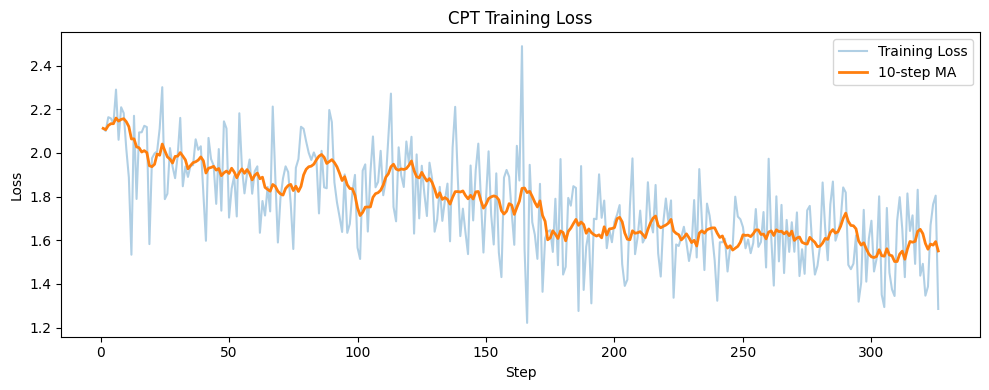

>> Loss plot saved: cpt_loss.png


In [22]:
# Stage 6E: Dynamic CPT loss summary

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

loss_values = [e["loss"] for e in trainer.state.log_history if "loss" in e]

half = len(loss_values) // 2

print("CPT Loss Summary")
print("-" * 20)
print(f"Logged steps           : {len(loss_values):,}")
print(f"First loss             : {loss_values[0]:.4f}")
print(f"Final loss             : {loss_values[-1]:.4f}")
print(f"Minimum loss           : {min(loss_values):.4f}")
print(f"Mean loss              : {np.mean(loss_values):.4f}")
print(f"First-half mean        : {np.mean(loss_values[:half]):.4f}")
print(f"Second-half mean       : {np.mean(loss_values[half:]):.4f}")

loss_df = pd.DataFrame({"step": loss_callback.steps, "loss": loss_callback.losses})
loss_df["ma"] = loss_df["loss"].rolling(window=10, min_periods=1).mean()

plt.figure(figsize=(10, 4))
plt.plot(loss_df["step"], loss_df["loss"], alpha=0.35, label="Training Loss")
plt.plot(loss_df["step"], loss_df["ma"], linewidth=2, label="10-step MA")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("CPT Training Loss")
plt.legend()
plt.tight_layout()
plt.savefig("cpt_loss.png", dpi=120)
plt.show()
print(">> Loss plot saved: cpt_loss.png")

### CPT Loss Observation

CPT ran for 326 optimizer steps (2 epochs over 655 training blocks, 163 steps per epoch) in about 3 min 16 s on the A100.

| Metric | Value |
|---|---|
| First loss | 2.1122 |
| Final loss | 1.2856 |
| Minimum loss | 1.2218 (around step 165) |
| Mean loss | 1.7556 |
| First-half mean | 1.8903 |
| Second-half mean | 1.6210 |

The second-half mean is about 14% lower than the first-half mean, and the 10-step moving average falls from about 2.1 to about 1.55–1.6. The starting loss of about 2.1 is in the 2–4 range expected for a pretrained model, so the model was loaded correctly and was not randomly initialised. The downward trend shows the model adapting to the finance and payments text.

Individual steps are noisy, with values between about 1.2 and 2.5, because each step averages only four 1,024-token blocks. The final value of 1.2856 is one low batch, not the trend. The moving average at the end is about 1.55, which is the better figure to quote. The spike of about 2.5 at step 164 falls at the epoch boundary and recovers immediately.

The curve flattens to roughly 1.6 over the last 100 steps, with no sharp drop at the start of epoch 2. That would be the usual sign of memorisation, so there is no sign of it here.

### Stage 6F: Save the CPT Model

The model obtained after continued pretraining is saved together with its tokenizer.

Saving the CPT checkpoint preserves the finance-adapted model for subsequent evaluation and QLoRA fine-tuning without requiring the CPT training process to be repeated.

In [23]:
# Stage 6F: Save CPT model and tokenizer

CPT_MODEL_DIR = Path("cpt_model")

print("Stage 6F: Saving CPT Model")
print("-" * 28)

model.save_pretrained(CPT_MODEL_DIR)
tokenizer.save_pretrained(CPT_MODEL_DIR)

assert CPT_MODEL_DIR.exists()
assert (CPT_MODEL_DIR / "config.json").exists()

print(f"Saved to : {CPT_MODEL_DIR}/")
print("\n>> [OK] CPT model and tokenizer saved.")

Stage 6F: Saving CPT Model
----------------------------
Saved to : cpt_model/

>> [OK] CPT model and tokenizer saved.


## Step 5: CPT Evaluation

This step evaluates whether continued pretraining improved the model's adaptation to the finance domain.

The evaluation includes:

- Computing perplexity on the held-out finance-domain sequences that were excluded from CPT.
- Comparing the **base SmolLM2-360M model** against the **CPT-adapted model** on the same held-out data.
- Re-running the same ten finance-domain prompts used before CPT and comparing the generated responses.
- Testing general-purpose prompts before and after CPT to identify possible catastrophic forgetting.

A lower held-out perplexity after CPT indicates improved predictive fit to the finance-domain corpus.

#### Stage 7A: Held-Out Perplexity Evaluation

Perplexity measures how well a language model predicts unseen text. It is calculated as the exponential of the average negative log-likelihood.

Both the original pretrained model and the CPT-adapted model are evaluated on the same held-out finance-domain sequences to provide a direct comparison.

Lower perplexity indicates better predictive performance on the held-out finance-domain text.

In [24]:
# Stage 7A: Perplexity evaluation function

import math
import torch


def calculate_perplexity(model, dataset, device):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for sample in dataset:
            input_ids = sample["input_ids"].unsqueeze(0).to(device)
            labels = sample["labels"].unsqueeze(0).to(device)

            outputs = model(
                input_ids=input_ids,
                labels=labels
            )

            # Causal LM loss predicts tokens 1...N from tokens 0...N-1
            predicted_tokens = labels.numel() - 1

            total_loss += outputs.loss.item() * predicted_tokens
            total_tokens += predicted_tokens

    average_nll = total_loss / total_tokens
    perplexity = math.exp(average_nll)

    return average_nll, perplexity


print("Stage 7A: Held-Out Evaluation Setup")
print("-" * 38)
print(f"Held-out sequences : {len(cpt_holdout_dataset)}")
print(f"Sequence length    : {CPT_SEQUENCE_LENGTH:,}")
print(
    f"Evaluation tokens  : "
    f"{len(cpt_holdout_dataset) * (CPT_SEQUENCE_LENGTH - 1):,}"
)

print("\n>> [OK] Perplexity evaluation function ready.")

Stage 7A: Held-Out Evaluation Setup
--------------------------------------
Held-out sequences : 74
Sequence length    : 1,024
Evaluation tokens  : 75,702

>> [OK] Perplexity evaluation function ready.


### Held-Out Evaluation Observation

The evaluation set is the 74 held-out blocks of 1,024 tokens. Perplexity is scored on 75,702 tokens, which is 74 × 1,023. The first token of each block has no preceding token to predict it, so each block contributes 1,023 predictions. The set is the same one used for the base model, so the two perplexity values come from identical text.

### Stage 7B: CPT Model Perplexity

The CPT model is evaluated on the held-out blocks that were never used in training. Perplexity is the exponential of the average negative log-likelihood per token, so a lower value means the model predicts unseen domain text better. The same function is used for the base model in Stage 7C so the two scores are directly comparable.

In [25]:
# Stage 7B: Evaluate CPT model perplexity

model.to(DEVICE)

cpt_nll, cpt_perplexity = calculate_perplexity(model, cpt_holdout_dataset, DEVICE)

print("Stage 7B: CPT Model Perplexity")
print("-" * 32)
print(f"Average NLL : {cpt_nll:.4f}")
print(f"Perplexity  : {cpt_perplexity:.4f}")
print("\n>> [OK] CPT model evaluation completed.")

Stage 7B: CPT Model Perplexity
--------------------------------
Average NLL : 1.8523
Perplexity  : 6.3744

>> [OK] CPT model evaluation completed.


### CPT Model Perplexity Observation

The CPT model's average negative log-likelihood on the held-out blocks is 1.8523, which gives a perplexity of 6.3744 (e^1.8523). In other words, the model is about as uncertain as choosing between roughly 6.4 equally likely tokens at each position.

This lower value compared with the base model is evidence of adaptation to the finance and payments text, but perplexity measures predicting text, not answering questions correctly. Stages 7D and 7E check generated answers and whether general knowledge is retained.

### Stage 7C: Base Model Perplexity

The original pretrained SmolLM2-360M model is evaluated on the **same held-out finance-domain sequences** used for the CPT model.

Using identical evaluation data provides a direct comparison between the original base model and the finance-adapted CPT model. A lower perplexity for the CPT model would indicate improved predictive fit to the held-out finance-domain corpus.

In [26]:
# Stage 7C: Evaluate base model perplexity

import gc
from transformers import AutoModelForCausalLM

model.to("cpu")
gc.collect()
torch.cuda.empty_cache()

print("Stage 7C: Base Model Perplexity")
print("-" * 33)
print("Loading original pretrained model...\n")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=MODEL_DTYPE
).to(DEVICE)

base_nll, base_perplexity = calculate_perplexity(base_model, cpt_holdout_dataset, DEVICE)

ppl_change = base_perplexity - cpt_perplexity
ppl_pct = ppl_change / base_perplexity * 100

print("Perplexity Comparison")
print("-" * 30)
print(f"Base model PPL : {base_perplexity:.4f}")
print(f"CPT model PPL  : {cpt_perplexity:.4f}")
print(f"Improvement    : {ppl_change:+.4f} ({ppl_pct:+.1f}%)")

if cpt_perplexity < base_perplexity:
    print("\n>> CPT reduced perplexity, domain adaptation worked.")
else:
    print("\n>> CPT did not reduce perplexity on this held-out set.")
    print("   Consider more corpus tokens or additional epochs.")

base_model.to("cpu")
del base_model
gc.collect()
torch.cuda.empty_cache()
model.to(DEVICE)

print("\n>> [OK] Perplexity evaluation complete.")

Stage 7C: Base Model Perplexity
---------------------------------
Loading original pretrained model...

Perplexity Comparison
------------------------------
Base model PPL : 7.9047
CPT model PPL  : 6.3744
Improvement    : +1.5303 (+19.4%)

>> CPT reduced perplexity, domain adaptation worked.

>> [OK] Perplexity evaluation complete.


### Base Model Perplexity Observation

The original SmolLM2-360M, evaluated on the same 74 held-out blocks, has a perplexity of 7.9047, which is an average negative log-likelihood of about 2.067 per token. This is the baseline for judging CPT. The base model is already a capable English model, so a single-digit perplexity is expected. The question is how much domain-specific text improves on it.

### Perplexity Comparison Observation

| Model | Perplexity | Average NLL |
|---|---|---|
| Base SmolLM2-360M | 7.9047 | about 2.067 |
| After CPT | 6.3744 | 1.8523 |

CPT lowered perplexity by 1.5303, a 19.4% reduction. This is inside the 10–40% range the assignment describes for a successful CPT run. Per token it is about 0.215 nats less uncertainty on text the model never trained on. The result is consistent with the loss curve and the low 2.7% held-out overlap from Stage 6B, so the gain reflects real adaptation to Indian regulatory and payments language.

Perplexity measures how well the model predicts the corpus, not whether its answers are correct. Stages 7D and 7E check the generated answers and whether general knowledge is retained.

#### Stage 7D: Domain Prompt Comparison

The same ten finance-domain prompts used for baseline inference before CPT are now evaluated using the CPT-adapted model.

Using identical prompts and generation settings enables a direct qualitative comparison between the base model and the domain-adapted model.

In [27]:
# Stage 7D: Post-CPT domain prompts (same prompts and GENERATE_KWARGS as Stage 5D)

model.eval()
cpt_responses = []

print("Stage 7D: Post-CPT Domain Prompt Evaluation")
print("-" * 45)
print(f"Generation: {GENERATE_KWARGS}\n")

for i, prompt in enumerate(all_domain_prompts, 1):
    response = generate_text(model, tokenizer, prompt)
    cpt_responses.append(response)
    print(f"Prompt {i}\n{prompt}\n\nCPT Response:\n{response}\n" + "-" * 70)

Stage 7D: Post-CPT Domain Prompt Evaluation
---------------------------------------------
Generation: {'max_new_tokens': 150, 'do_sample': False, 'repetition_penalty': 1.1, 'no_repeat_ngram_size': 4}

Prompt 1
Explain the risks faced by individual traders in equity derivatives markets.

CPT Response:
(b) 
Discuss the role of insurance companies and other intermediaries in facilitating trading activities in equity derivatives market.

Q.10 
(a) 
Describe the structure, functions and responsibilities of a stock exchange. 
(b ) 
What are the various types of securities traded on stock exchanges? 
(c) 
List out the major stock exchanges in India. 
Briefly explain their operations. 
How do they differ from each other? 
In which states/UTs does BSE/NSE operate? 
Where is NSE registered? 
Brief details about the SEBI regulations applicable to listed entities. 
State whether there are any restrictions on listing
----------------------------------------------------------------------
Prompt 2
Ex

### Post-CPT Inference Observation

After CPT the model's output moves toward the corpus in vocabulary and format, but its factual accuracy is still weak.

**What improved**
- **Domain terms:** The model uses Indian regulatory language in places. It names NPCI, RBI and SEBI, writes amounts in ₹ lakh and crore (Prompt 6), and uses the SEBI term "specified securities" in its buy-back definition (Prompt 3). Prompt 8 includes a "Stock Exchange Buy-Back", which is close to a real buy-back route.
- **Document style:** Prompt 10 is continued as lettered regulatory clauses (a, b, c), and Prompt 7 turns into a textbook chapter ("In this chapter, we will explore…"), so the model has picked up the register of formal documents.

**What did not improve**
- **Invented facts:**
  - Prompt 6 invents fiscal years ("FY37–FY38", "FY29–FY40"), blames a decline on "the pandemic" and cites "Source: RBI" for a SEBI study.
  - Prompt 5 says the Payments Vision "is based on three pillars", but the document describes five.
- **Wrong concepts:**
  - Prompt 3 says a buy-back increases the number of outstanding shares. A buy-back reduces them. It then drifts to "buy-downs".
  - Prompt 8 lists "Direct Buy-Back" and "Reverse Split" as buy-back methods. SEBI's methods are the tender offer and the open market.
  - Prompt 9 describes a security receipt as a security agreement over collateral. It is an instrument issued by the ARC to investors.
  - Prompt 10 describes disclosure of "details of its proposed listing" and the period between a draft and final offer document. That is IPO offer-document language, not the continuing disclosures of the LODR Regulations.
- **Questions not answered:** Prompts 1, 2 and 4 are continued as exam-paper question lists ("Q.10 (a)… (b)…") on other topics, such as stock exchanges and credit risk, instead of explanations. Prompt 4 never mentions asset reconstruction companies. A base language model continues text. It does not follow instructions, and CPT trained it only on documents, not on question-and-answer pairs.

**Conclusion:** With 0.75M training tokens and 2 epochs, CPT shifted vocabulary and style but did not store dependable facts. Perplexity fell by 19.4%, yet greedy generations can still be wrong. This is the reason for the QLoRA stage. Instruction examples grounded in the documents teach the answer format and the correct figures.

#### Stage 7E: Catastrophic Forgetting Check

Continued pretraining on a specialized domain can potentially reduce a model's performance on general-domain tasks, a phenomenon known as **catastrophic forgetting**.

To check for this effect, the original base model and the CPT-adapted model are evaluated using the same general-purpose prompts with identical generation settings.

The responses are compared qualitatively and classified as **Retained** or **Degraded** based on whether the CPT model preserves the general capability demonstrated by the base model.

In [28]:
# Stage 7E: Catastrophic forgetting (same GENERATE_KWARGS as every other stage)

general_prompts = [
    "Explain why the sky appears blue.",
    "What are the main benefits of regular physical exercise?",
    "Explain the difference between a renewable and non-renewable energy source.",
    "The capital of France is",
    "Water boils at",
]

model.to(DEVICE)
model.eval()
cpt_general_outputs = [generate_text(model, tokenizer, p) for p in general_prompts]

# Load a fresh base model for comparison
model.to("cpu")
gc.collect()
torch.cuda.empty_cache()

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=MODEL_DTYPE
).to(DEVICE)
base_model.eval()
base_general_outputs = [generate_text(base_model, tokenizer, p) for p in general_prompts]

base_model.to("cpu")
del base_model
gc.collect()
torch.cuda.empty_cache()
model.to(DEVICE)

print("Stage 7E: Catastrophic Forgetting Comparison")
print("-" * 45)
for i, prompt in enumerate(general_prompts):
    print(f"\nPrompt {i+1}: {prompt}")
    print("\nBASE RESPONSE:")
    print(base_general_outputs[i])
    print("\nCPT RESPONSE:")
    print(cpt_general_outputs[i])
    print("-" * 70)

Stage 7E: Catastrophic Forgetting Comparison
---------------------------------------------

Prompt 1: Explain why the sky appears blue.

BASE RESPONSE:
The light from the sun is made up of all colors, or wavelengths, of visible light. When sunlight passes through Earth's atmosphere, it collides with molecules and particles in the air. These collisions scatter the shorter wavelength colors (blue) more than longer ones (red), green, yellow, etc., making the sky appear blue.

2. What are some other ways that we can see things?

We can also see things by looking at them directly, using a microscope to look at very small objects, or by observing changes in an object over time. For example, if you drop a pebble into a pond, ripples will spread out across the water surface. By watching these ripples develop, you can learn about how waves

CPT RESPONSE:
• 10.2.3 Describe how light is reflected from objects and how this affects their colour, including white light as a mixture of all colours.

#

### Catastrophic Forgetting Observation

CPT kept the model's general fluency and most of its general knowledge. One of the five prompts degraded. Five prompts is a small sample, so treat this as a qualitative check, not a measurement.

| Prompt | Base | After CPT | Verdict |
|---|---|---|---|
| 1. Why the sky is blue | Correct (scattering of shorter wavelengths) | Fails to explain: lists curriculum-style learning outcomes (10.2.3, 10A, A.1.1) | Degraded |
| 2. Benefits of exercise | Correct, with web-page artifacts ("You might be interested…") | Correct and cleaner | Retained |
| 3. Renewable vs non-renewable | Correct | Correct, then continues with related questions about India | Retained |
| 4. Capital of France | "Paris", with invented details (20 million people, 13 districts, 1875 light bulb) | "the city of Paris", then invented details: Lyon called both "second largest" and "third… after Paris and Marseille", invented populations, and Deauville listed as an industrial centre | Retained (both models add invented details) |
| 5. Water boils at | "100 degrees Celsius", then contradicts itself with 105 | "100 degrees Celsius", then the same 105 contradiction and a drift into solar thermal power | Retained (same error as the base) |

- **No finance drift:** None of the five general answers mentions RBI, SEBI, UPI or other finance terms. Domain training did not leak into general topics.
- **Fluency held:** Prompts 2 and 3 are as good as or better than the base answers.
- **Regression:** Only Prompt 1 is clearly worse. The sky answer is not an answer at all. The France answer gives the right capital but then adds contradictory facts, and the base answer also contained invented details. The 105 °C error comes from the base model, not CPT. This is mild degradation of instruction-style answering, not a collapse of general knowledge.
- **Document continuation:** The curriculum list in Prompt 1 shows the model continuing in a different document style instead of answering. A base language model does this, and CPT has made it more likely.

Greedy outputs can change from one run to the next because of small numeric differences, so individual answers here may differ on a re-run. Perplexity is the more stable measure.

## Step 6: Instruction Dataset Preparation

The cleaned finance-domain corpus produced in Step 1 is now transformed into an instruction-response dataset for supervised QLoRA fine-tuning.

Each example contains:

- `instruction` — a question or task derived from the finance-domain text.
- `response` — an answer grounded directly in the corresponding corpus content.

The resulting examples are saved in **JSONL format** and divided into an **80/20 training and evaluation split** for subsequent QLoRA fine-tuning.

#### Stage 8A: Load Cleaned Finance Corpus

The 18 cleaned `.txt` documents from the CPT corpus are loaded as the source material for instruction-dataset construction.

Only the cleaned corpus is used so that the instruction-response examples remain grounded in the same finance domain used during continued pretraining.

In [29]:
# Stage 8A: Load cleaned corpus for instruction generation

cleaned_files = sorted(FINAL_CORPUS_DIR.glob("*.txt"))

instruction_source_documents = []

for file_path in cleaned_files:
    text = file_path.read_text(encoding="utf-8").strip()

    instruction_source_documents.append({
        "document": file_path.name,
        "text": text
    })

print("Stage 8A: Instruction Dataset Source")
print("-------------------------------------")
print(f"Source documents : {len(instruction_source_documents)}")

for i, document in enumerate(instruction_source_documents, 1):
    print(
        f"{i:02d}. {document['document']} "
        f"({len(document['text']):,} characters)"
    )

assert len(instruction_source_documents) == expected_pdf_count

print("\n>> [OK] Cleaned finance corpus loaded.")

Stage 8A: Instruction Dataset Source
-------------------------------------
Source documents : 18
01. Profitability of Individual Traders in the Equity Derivatives Segment (FY25–FY26).txt (138,593 characters)
02. RBI - Asset Reconstruction Companies Directions 2025.txt (130,075 characters)
03. RBI - Asset Reconstruction Companies – Credit Information Reporting Directions 2025.txt (74,228 characters)
04. RBI - Asset Reconstruction Companies – Know Your Customer Directions 2025.txt (163,517 characters)
05. RBI - Asset Reconstruction Companies – Treatment of Wilful Defaulters and Large Defaulters Directions 2025.txt (17,248 characters)
06. RBI - Benchmarking Indias Payments Systems - 2022.txt (138,602 characters)
07. RBI - Digitalisation and Payment Revolution in India 2024.txt (102,973 characters)
08. RBI - Master Direction on Regulation of Payment Aggregator.txt (43,660 characters)
09. RBI - Payment and Settlement Systems and Information Technology 2025-26.txt (34,951 characters)
10. RBI

#### Stage 8B: Construct Curated Grounded Instruction-Response Pairs

Automatic paragraph-to-question conversion was avoided because the extracted PDF corpus contains tables, page headers, contents pages, acknowledgements, and other material that does not form meaningful instruction-response examples.

Instead, a compact instruction dataset was manually and heuristically curated from substantive findings and regulatory information contained in the cleaned finance corpus.

The dataset covers:
- Equity-derivatives participation and profitability.
- SEBI buy-back regulations.
- India's digital-payment transformation.
- UPI.
- Payment-system benchmarking.
- Payment and settlement systems.

Each response is based on information represented in the cleaned domain documents.

In [30]:
# Stage 8B: Curated finance instruction-response dataset

instruction_examples = [

    # Equity Derivatives
    {
        "instruction":
            "What does SEBI's study indicate about profitability among individual traders in the equity derivatives segment?",
        "response":
            "SEBI's analysis shows that a very large majority of individual traders in the equity derivatives segment incurred net losses. The findings highlight the substantial financial risk faced by retail participants in derivatives trading.",
        "source_document":
            "Profitability of Individual Traders in the  Equity Derivatives Segment (FY25–FY26).txt"
    },

    {
        "instruction":
            "Why did SEBI examine individual trader profitability in the equity derivatives segment?",
        "response":
            "The study was undertaken to reassess trading outcomes following rapid growth in retail participation, changes in market structure, and new regulatory measures in the equity derivatives segment.",
        "source_document":
            "Profitability of Individual Traders in the  Equity Derivatives Segment (FY25–FY26).txt"
    },

    {
        "instruction":
            "What factors does SEBI examine when studying trading outcomes of individual derivatives traders?",
        "response":
            "SEBI examines trading activity, profitability and investor characteristics, including factors such as trading activity, portfolio size, age, gender and location, to understand individual participation in the equity derivatives market.",
        "source_document":
            "Profitability of Individual Traders in the  Equity Derivatives Segment (FY25–FY26).txt"
    },

    {
        "instruction":
            "What aspects of individual trader behaviour are examined in SEBI's equity derivatives study?",
        "response":
            "The study examines trading strategies, capital employed, persistence in trading and behavioural patterns among individual participants in the equity derivatives segment.",
        "source_document":
            "Trading Behaviour of Individual Traders in the  Equity Derivatives Segment (FY2025-26).txt"
    },

    # SEBI Buy-back Regulations
    {
        "instruction":
            "What is a tender-offer route for a buy-back of securities?",
        "response":
            "Under the tender-offer route, a company buys back specified securities from its existing security holders on a proportionate basis.",
        "source_document":
            "SEBI - Buy-Back of Securities.txt"
    },

    {
        "instruction":
            "What methods may a company use to buy back its specified securities?",
        "response":
            "A company may conduct a buy-back from existing security holders through a proportionate tender offer, through permitted open-market mechanisms, or from odd-lot holders, subject to the applicable SEBI regulations.",
        "source_document":
            "SEBI - Buy-Back of Securities.txt"
    },

    {
        "instruction":
            "Can a company conduct a buy-back through a private negotiated deal?",
        "response":
            "No. The buy-back regulations prohibit a company from buying back specified securities through negotiated deals, spot transactions or private arrangements.",
        "source_document":
            "SEBI - Buy-Back of Securities.txt"
    },

    {
        "instruction":
            "To which companies do SEBI's Buy-Back of Securities Regulations apply?",
        "response":
            "The regulations apply to the buy-back of shares or other specified securities by companies whose securities are listed on a stock exchange.",
        "source_document":
            "SEBI - Buy-Back of Securities.txt"
    },

    {
        "instruction":
            "What information must be specified when a buy-back is authorised at a maximum price?",
        "response":
            "The applicable resolution must specify the maximum price at which the company's securities may be bought back.",
        "source_document":
            "SEBI - Buy-Back of Securities.txt"
    },

    {
        "instruction":
            "What role does a merchant banker have in a regulated securities buy-back?",
        "response":
            "The buy-back framework requires the appointment of a merchant banker for applicable buy-back procedures, including responsibilities connected with regulatory compliance and public disclosures.",
        "source_document":
            "SEBI - Buy-Back of Securities.txt"
    },

    # Digitalisation and Payments

    {
        "instruction":
            "How has digitalisation changed India's payment landscape?",
        "response":
            "Digitalisation has transformed payment services by improving their reach, ease and speed while supporting wider participation and financial inclusion.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "What role has UPI played in India's digital-payment transformation?",
        "response":
            "UPI has transformed India's retail payment landscape by providing an interoperable real-time account-to-account payment system and has emerged as a preferred method of retail payment.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "What factors support the adoption of digital payments?",
        "response":
            "Digital-payment adoption is supported by factors including banking penetration, technological advancement, formalisation of the economy and demographic characteristics such as a relatively young population.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "What factors shaped the development of India's modern payment architecture?",
        "response":
            "India's payment architecture developed through a combination of technological advancement, institutions, market participants, policy interventions and cooperation between public and private entities.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "How did the COVID-19 pandemic affect digital payments in India?",
        "response":
            "The COVID-19 pandemic accelerated the adoption of digital payments as consumers and businesses increasingly used contactless transactions during periods of social distancing and lockdowns.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "How did demonetisation affect retail electronic payments in India?",
        "response":
            "The RBI observed a sharp acceleration in retail electronic payments around the 2016 demonetisation period, indicating a structural shift toward electronic payment methods.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "What is UPI Lite intended to provide?",
        "response":
            "UPI Lite was introduced as a simplified UPI facility intended to make small-value payments faster and more convenient, including transactions that do not require normal PIN authentication within the permitted limits.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "What is the purpose of UPI Lite X?",
        "response":
            "UPI Lite X extends small-value digital-payment capability to offline transactions and uses near-field communication technology for supported payments.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "What does interoperability contribute to India's payment system?",
        "response":
            "Interoperability allows users and payment systems to interact across platforms, increasing convenience and helping create an efficient and widely accessible retail-payment ecosystem.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "What broader economic goals are supported by India's digital-payment development?",
        "response":
            "The development of digital payments supports financial inclusion, payment-system efficiency and growth of the digital economy.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    # Payment-System Benchmarking
    {
        "instruction":
            "Why does RBI benchmark India's payment systems against other countries?",
        "response":
            "Benchmarking helps assess India's progress relative to major international payment systems and provides a basis for identifying areas where payment-system efficiency and digitalisation can be strengthened.",
        "source_document":
            "RBI - Benchmarking Indias Payments Systems - 2022.txt"
    },

    {
        "instruction":
            "How were countries classified in RBI's payment-system benchmarking exercise?",
        "response":
            "Countries were grouped using performance categories such as Leader, Strong, Moderate and Weak according to their relative ranking on payment-system indicators.",
        "source_document":
            "RBI - Benchmarking Indias Payments Systems - 2022.txt"
    },

    {
        "instruction":
            "What was the objective of RBI's international payment-system benchmarking exercise?",
        "response":
            "The objective was to understand the payment systems operating in India, compare usage preferences with other countries and provide a basis for analysing the efficiency of India's payment systems.",
        "source_document":
            "RBI - Benchmarking Indias Payments Systems - 2022.txt"
    },

    {
        "instruction":
            "What types of payment-system areas are considered in RBI's benchmarking exercise?",
        "response":
            "The benchmarking exercise considers areas such as payment-system regulation, cards, cash and ATMs, credit transfers, electronic money, government electronic payments and central-bank oversight.",
        "source_document":
            "RBI - Benchmarking Indias Payments Systems - 2022.txt"
    },

    # Payment and Settlement Systems
    {
        "instruction":
            "What has RBI focused on when expanding digital payments across society?",
        "response":
            "RBI has focused on expanding adoption of digital payments across different segments of society through innovation and a supportive regulatory framework.",
        "source_document":
            "RBI - Payment and Settlement Systems and Information Technology 2025-26.txt"
    },

    {
        "instruction":
            "Why are innovation and regulation both important for payment systems?",
        "response":
            "Innovation can improve the reach and functionality of payment services, while an appropriate regulatory framework supports safety, reliability and orderly development of the payment ecosystem.",
        "source_document":
            "RBI - Payment and Settlement Systems and Information Technology 2025-26.txt"
    },

    # SEBI Infrastructure Investment Trusts

{
    "instruction":
        "What responsibility does the trustee of an Infrastructure Investment Trust have toward unit holders?",
    "response":
        "The trustee holds the InvIT assets for the benefit of unit holders and oversees the activities of the investment manager and project manager to ensure compliance with the applicable regulations.",
    "source_document":
        "SEBI Infrastructure Investment Trusts.txt"
},

{
    "instruction":
        "How frequently must a full valuation of an Infrastructure Investment Trust be conducted?",
    "response":
        "A full valuation of the InvIT assets must be conducted at least once every financial year by an eligible valuer, and the valuation covers all InvIT assets, including physical inspection of infrastructure projects.",
    "source_document":
        "SEBI Infrastructure Investment Trusts.txt"
},

{
    "instruction":
        "How often must distributions be declared by publicly offered and privately placed Infrastructure Investment Trusts?",
    "response":
        "Publicly offered InvITs must declare distributions at least once every six months in each financial year, while privately placed InvITs must declare distributions at least once every financial year.",
    "source_document":
        "SEBI Infrastructure Investment Trusts.txt"
},
    # Added for the expanded corpus (Banking, Payments Vision, Buy-back and Takeover Regulations)
    {
        "instruction": "What are the five pillars of the RBI's Payments Vision 2025?",
        "response": 'Payments Vision 2025 is presented across five anchor goalposts: integrity, inclusion, innovation, institutionalisation and internationalisation.',
        "source_document": 'RBI - Payments Vision 2025.txt'
    },
    {
        "instruction": "What four goalposts did the RBI's earlier Payments Vision 2021 set?",
        "response": 'Payments Vision 2021 set four goalposts of Competition, Cost, Convenience and Confidence, with 36 specific action points and 12 expected outcomes.',
        "source_document": 'RBI - Payments Vision 2025.txt'
    },
    {
        "instruction": 'How does Payments Vision 2025 propose to promote inclusion in digital payments?',
        "response": 'Inclusion is to be promoted through the collection and publication of disaggregated payment data, customer awareness across geographies and customer segments, identification of the spatial penetration of digital payment acceptance infrastructure across states and districts, and a review of the scope of the PIDF Scheme.',
        "source_document": 'RBI - Payments Vision 2025.txt'
    },
    {
        "instruction": 'Which cross-border payment challenges does Payments Vision 2025 aim to address?',
        "response": 'Payments Vision 2025 builds on the G-20 focus on enhancing cross-border payments by addressing four key challenges: cost, speed, access and transparency.',
        "source_document": 'RBI - Payments Vision 2025.txt'
    },
    {
        "instruction": 'What minimum net owned fund must an asset reconstruction company hold to start business?',
        "response": 'To commence the business of securitisation or asset reconstruction, an ARC must have a minimum net owned fund of ₹300 crore. ARCs that existed on October 11, 2022 must reach this level by March 31, 2026.',
        "source_document": 'RBI - Asset Reconstruction Companies Directions 2025.txt'
    },
    {
        "instruction": 'What capital adequacy ratio must an asset reconstruction company maintain?',
        "response": 'An ARC must maintain, on an ongoing basis, a capital adequacy ratio of at least 15 percent of its total risk-weighted assets.',
        "source_document": 'RBI - Asset Reconstruction Companies Directions 2025.txt'
    },
    {
        "instruction": 'How much must an asset reconstruction company invest in the security receipts it issues?',
        "response": "For each class of security receipts issued under each scheme, an ARC must invest at least 15 percent of the transferors' investment in the security receipts or 2.5 percent of the total security receipts issued, whichever is higher, on an ongoing basis until all the security receipts are redeemed.",
        "source_document": 'RBI - Asset Reconstruction Companies Directions 2025.txt'
    },
    {
        "instruction": 'Within what time must an asset reconstruction company get its security receipts rated?',
        "response": 'An ARC must obtain an initial rating or grading of its security receipts from a SEBI-registered credit rating agency within six months from the date of acquisition of the assets, and must declare the net asset value of the security receipts.',
        "source_document": 'RBI - Asset Reconstruction Companies Directions 2025.txt'
    },
    {
        "instruction": 'How often must an asset reconstruction company report large defaulters to credit information companies?',
        "response": 'An ARC must submit information on large defaulters to all credit information companies at monthly intervals, covering a list of suit-filed accounts and a list of non-suit-filed accounts that are classified as doubtful or loss.',
        "source_document": 'RBI - Asset Reconstruction Companies – Treatment of Wilful Defaulters and Large Defaulters Directions 2025.txt'
    },
    {
        "instruction": "What is the maximum size of a buy-back under SEBI's buy-back regulations?",
        "response": "The maximum limit of any buy-back is twenty-five per cent or less of the aggregate of the paid-up capital and free reserves of the company. For a buy-back of equity shares in a financial year, the twenty-five per cent refers to the company's total paid-up equity capital in that financial year.",
        "source_document": 'SEBI - Buyback of Securities & Substantial Acquisition of Shares and Takeovers Regulations.txt'
    },
    {
        "instruction": "How long does a company have to complete a buy-back under SEBI's buy-back regulations?",
        "response": 'Every buy-back must be completed within one year from the date of passing of the special resolution at the general meeting, or the resolution passed by the board of directors, as the case may be.',
        "source_document": 'SEBI - Buyback of Securities & Substantial Acquisition of Shares and Takeovers Regulations.txt'
    },
    {
        "instruction": 'How soon can a company make a fresh buy-back offer after an earlier one?',
        "response": 'A company shall not make any offer of buy-back within a period of one year reckoned from the date of closure of the preceding offer of buy-back.',
        "source_document": 'SEBI - Buyback of Securities & Substantial Acquisition of Shares and Takeovers Regulations.txt'
    }
]


instruction_df = pd.DataFrame(instruction_examples)

print("Stage 8B: Curated Instruction Dataset")
print("--------------------------------------")
print(f"Total examples       : {len(instruction_df)}")
print(f"Unique instructions  : {instruction_df['instruction'].nunique()}")
print(f"Source documents used: {instruction_df['source_document'].nunique()}")

print("\nExamples per source:")
print(
    instruction_df["source_document"]
    .value_counts()
)

print("\nSample pair:")
print("Instruction:")
print(instruction_df.iloc[0]["instruction"])

print("\nResponse:")
print(instruction_df.iloc[0]["response"])

print("\n>> [OK] Curated grounded instruction dataset created.")

Stage 8B: Curated Instruction Dataset
--------------------------------------
Total examples       : 41
Unique instructions  : 41
Source documents used: 11

Examples per source:
source_document
RBI - Digitalisation and Payment Revolution in India 2024.txt                                                     10
SEBI - Buy-Back of Securities.txt                                                                                  6
RBI - Benchmarking Indias Payments Systems - 2022.txt                                                              4
RBI - Asset Reconstruction Companies Directions 2025.txt                                                           4
RBI - Payments Vision 2025.txt                                                                                     4
SEBI - Buyback of Securities & Substantial Acquisition of Shares and Takeovers Regulations.txt                     3
Profitability of Individual Traders in the  Equity Derivatives Segment (FY25–FY26).txt                   

### Instruction Dataset Observation

The curated dataset has 41 instruction–response pairs, all with unique instructions. Each pair is written from facts in the source documents, and the dataset covers 11 of the 18 corpus documents.

| Area | Examples | Main sources |
|---|---|---|
| Digital payments | 20 | Digitalisation and Payment Revolution 2024 (10), Benchmarking India's Payment Systems (4), Payments Vision 2025 (4), Payment and Settlement Systems and IT 2025-26 (2) |
| Capital markets | 16 | SEBI Buy-Back of Securities (6), SEBI Buy-back & SAST Regulations (3), Infrastructure Investment Trusts (3), trader profitability (3), trading behaviour (1) |
| Banking | 5 | ARC Directions 2025 (4), ARC wilful and large defaulters Directions (1) |

The spread is reasonable: payments, capital markets and banking are all present. Coverage is uneven, though. The Digitalisation document supplies 10 examples (24%), and seven corpus documents have none. These are the Listing Obligations (LODR) master circular, the UPI Annual Report, the Payment Aggregator Master Direction, the ARC KYC and Credit Information Directions, and the Municipal Debt and Investor Protection Fund documents. The SFT model will therefore be weakest on LODR, UPI statistics and payment aggregators.

The responses are short, factual and written in the source's wording. The sample pair on trader profitability states the finding and its implication in two sentences, without invented figures. This is the answer style the SFT stage should teach, as a replacement for the question-paper continuation seen after CPT.

With only 41 examples, the SFT stage can teach format and a set of core facts, not broad domain knowledge. It is a small dataset, so the evaluation set of about 8 examples is a rough signal.

#### Stage 8C: Validate Instruction-Response Pairs

The curated dataset is checked before saving.

Validation ensures that:
- Every example contains a non-empty instruction.
- Every example contains a non-empty response.
- Instructions are unique.
- Exact duplicate instruction-response pairs are absent.
- Administrative PDF text such as acknowledgements is not present in the training responses.

The source-document field is retained during validation for traceability but is not required in the final JSONL file.

In [31]:
# Stage 8C: Validate instruction dataset

assert len(instruction_df) > 0

assert instruction_df["instruction"].notna().all()
assert instruction_df["response"].notna().all()

assert (
    instruction_df["instruction"]
    .str.strip()
    .ne("")
    .all()
)

assert (
    instruction_df["response"]
    .str.strip()
    .ne("")
    .all()
)

duplicate_pairs = instruction_df.duplicated(
    subset=["instruction", "response"]
).sum()

admin_terms = [
    "gratefully acknowledge",
    "special thanks are due",
    "table of contents"
]

admin_matches = 0

for response in instruction_df["response"]:
    lower = response.lower()

    if any(term in lower for term in admin_terms):
        admin_matches += 1


print("Stage 8C: Dataset Validation")
print("-----------------------------")
print(f"Examples              : {len(instruction_df)}")
print(f"Duplicate pairs       : {duplicate_pairs}")
print(f"Administrative matches: {admin_matches}")

assert duplicate_pairs == 0
assert admin_matches == 0

print("\n>> [OK] Instruction dataset validation passed.")

Stage 8C: Dataset Validation
-----------------------------
Examples              : 41
Duplicate pairs       : 0
Administrative matches: 0

>> [OK] Instruction dataset validation passed.


### Dataset Validation Observation

The validation passed all four checks on the 41 examples:

- **Present and non-empty:** every pair has a non-empty instruction and response.
- **No duplicates:** 0 repeated instruction–response pairs.
- **No administrative text:** 0 responses contain front-matter phrases such as "gratefully acknowledge", "special thanks are due" or "table of contents".

These checks are structural. They confirm the data is well formed and free of boilerplate. They don't confirm that each answer is factually correct. Correctness comes from writing each response from the source document, and the 12 examples added for the new documents were checked against the extracted PDF text.

#### Stage 8D: Save Instruction Dataset as JSONL

The validated examples are saved in the required JSONL format.

Only the two assignment-required fields are written to the final dataset:

- `instruction`
- `response`

Source-document metadata was used during construction and validation but is excluded from the submitted JSONL file.

In [32]:
# Stage 8D: Save final instruction dataset

import json
from pathlib import Path

INSTRUCTION_DATASET_PATH = Path("instruction_dataset.jsonl")

final_instruction_df = instruction_df[
    ["instruction", "response"]
].copy()

with open(
    INSTRUCTION_DATASET_PATH,
    "w",
    encoding="utf-8"
) as f:

    for record in final_instruction_df.to_dict(
        orient="records"
    ):
        f.write(
            json.dumps(
                record,
                ensure_ascii=False
            ) + "\n"
        )


print("Stage 8D: JSONL Export")
print("----------------------")
print(f"Output file : {INSTRUCTION_DATASET_PATH}")
print(f"Examples    : {len(final_instruction_df)}")

print("\nFirst JSONL record:")
print(
    json.dumps(
        final_instruction_df.iloc[0].to_dict(),
        indent=2,
        ensure_ascii=False
    )
)

print("\n>> [OK] instruction_dataset.jsonl saved.")

Stage 8D: JSONL Export
----------------------
Output file : instruction_dataset.jsonl
Examples    : 41

First JSONL record:
{
  "instruction": "What does SEBI's study indicate about profitability among individual traders in the equity derivatives segment?",
  "response": "SEBI's analysis shows that a very large majority of individual traders in the equity derivatives segment incurred net losses. The findings highlight the substantial financial risk faced by retail participants in derivatives trading."
}

>> [OK] instruction_dataset.jsonl saved.


### JSONL Export Observation

The 41 validated examples were saved to `instruction_dataset.jsonl`, one JSON record per line. Each record has two fields, `instruction` and `response`. The first record, on SEBI's findings about trader profitability, shows the format: a short question followed by a two-sentence factual answer. The source-document name is not exported, so the JSONL file is the training data on its own.

JSONL is the format Hugging Face `datasets` reads directly. The next stage splits this file into training and evaluation sets.

#### Stage 8E: Create 80/20 Training and Evaluation Split

The instruction dataset is randomly shuffled using a fixed seed and divided into:

- **80% training examples**
- **20% evaluation examples**

A fixed random seed makes the split reproducible.

The evaluation examples are excluded from QLoRA training and retained for subsequent evaluation.

In [33]:
# Stage 8E: Reproducible 80/20 split

import random

records = final_instruction_df.to_dict(
    orient="records"
)

random.Random(42).shuffle(records)

split_index = round(
    len(records) * 0.80
)

train_records = records[:split_index]
eval_records = records[split_index:]

TRAIN_JSONL_PATH = Path(
    "instruction_dataset_train.jsonl"
)

EVAL_JSONL_PATH = Path(
    "instruction_dataset_eval.jsonl"
)


def save_jsonl(records, path):

    with open(path, "w", encoding="utf-8") as f:

        for record in records:
            f.write(
                json.dumps(
                    record,
                    ensure_ascii=False
                ) + "\n"
            )


save_jsonl(
    train_records,
    TRAIN_JSONL_PATH
)

save_jsonl(
    eval_records,
    EVAL_JSONL_PATH
)


print("Stage 8E: Instruction Dataset Split")
print("------------------------------------")
print(f"Total examples : {len(records)}")
print(f"Training       : {len(train_records)}")
print(f"Evaluation     : {len(eval_records)}")

print(
    f"\nTraining ratio : "
    f"{len(train_records) / len(records):.1%}"
)

print(
    f"Evaluation ratio: "
    f"{len(eval_records) / len(records):.1%}"
)

assert (
    len(train_records) +
    len(eval_records)
    == len(records)
)

print("\n>> [OK] 80/20 instruction split created.")

Stage 8E: Instruction Dataset Split
------------------------------------
Total examples : 41
Training       : 33
Evaluation     : 8

Training ratio : 80.5%
Evaluation ratio: 19.5%

>> [OK] 80/20 instruction split created.


### Instruction Split Observation

The 41 examples were shuffled with a fixed seed (42) and split into 33 training and 8 evaluation examples (80.5% / 19.5%). The split is saved as `instruction_dataset_train.jsonl` and `instruction_dataset_eval.jsonl`. The fixed seed makes the split reproducible, and the check confirms no example was lost or duplicated between the two sets.

The split is a random shuffle, not stratified by source document. The evaluation set is therefore a small random sample of 8 examples, and several of them come from documents that also supply training examples. This makes the evaluation loss a rough measure of how well the model learned the answer format and the content of these documents. It is not a test of generalisation to new documents. With 33 training examples the model sees about 8 batches per epoch.

## Step 7: QLoRA Instruction Fine-Tuning

The CPT checkpoint is now instruction fine-tuned using Quantized Low-Rank Adaptation (QLoRA).

The assignment's **Balanced Adapter configuration** is used:

- LoRA rank (`r`) = 16
- LoRA alpha = 32
- Target modules = `q_proj`, `v_proj`
- 4-bit model quantization

Only the LoRA adapter parameters are trained while the underlying CPT model remains quantized and frozen, substantially reducing GPU-memory requirements.

#### Stage 9A: Prepare QLoRA Libraries

The QLoRA stage requires `peft`, `bitsandbytes`, `trl`, and `datasets`.

Only missing packages are installed so that existing environment versions are left unchanged wherever possible.

In [34]:
# Stage 9A: Check/install QLoRA dependencies

import importlib.util
import subprocess
import sys

required_packages = {
    "peft": "peft",
    "bitsandbytes": "bitsandbytes",
    "trl": "trl",
    "datasets": "datasets"
}

for module_name, package_name in required_packages.items():

    if importlib.util.find_spec(module_name) is None:
        print(f">> Installing missing package: {package_name}")

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name
        ])

    else:
        print(f">> [OK] {package_name}")


print("\n>> [OK] QLoRA dependencies ready.")

>> [OK] peft
>> [OK] bitsandbytes
>> [OK] trl
>> [OK] datasets

>> [OK] QLoRA dependencies ready.


#### QLoRA Dependency Observation

The packages needed for QLoRA (`peft`, `bitsandbytes`, `trl`, `datasets`) are installed and importable in the course environment, so Part B can run without further setup.

#### Stage 9B: Release GPU Memory

The full-precision models used during CPT evaluation are removed from memory before loading the 4-bit QLoRA model.

This avoids unnecessary GPU-memory usage on the Tesla T4.

In [48]:
# Stage 9B: Release previous model objects

import gc
import torch

for variable_name in [
    "model",
    "base_model",
    "cpt_eval_model"
]:
    if variable_name in globals():
        del globals()[variable_name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Stage 9B: Release previous model objects")
print("----------------------------------------")
print("GPU cache cleared.")

if torch.cuda.is_available():
    free_bytes, total_bytes = torch.cuda.mem_get_info()

    print(
        f"Free GPU memory : "
        f"{free_bytes / 1024**3:.2f} GiB"
    )

    print(
        f"Total GPU memory: "
        f"{total_bytes / 1024**3:.2f} GiB"
    )

print("\n>> [OK] GPU prepared for QLoRA.")

Stage 9B: Release previous model objects
----------------------------------------
GPU cache cleared.
Free GPU memory : 72.23 GiB
Total GPU memory: 79.15 GiB

>> [OK] GPU prepared for QLoRA.


### GPU Preparation Observation

The earlier CPT and evaluation model objects were released and the GPU cache was cleared before QLoRA training. 72.59 GiB of the 79.15 GiB total is free, so about 6.6 GiB is still in use. That is memory held by the CUDA context and by objects that are still referenced in the notebook session. It is small next to what is needed. The 4-bit model and LoRA adapters need only a few gigabytes, so the GPU has plenty of room for QLoRA.

#### Stage 9C: Load CPT Model in 4-bit Precision

The CPT checkpoint from Part A is loaded using 4-bit NF4 quantization through `bitsandbytes`.

FP16 is used for 4-bit computation on the Tesla T4. The tokenizer saved with the CPT checkpoint is reused to preserve vocabulary alignment.

In [49]:
# Stage 9C: Load CPT model for QLoRA

from pathlib import Path

import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig
)

CPT_MODEL_DIR = Path("cpt_model")

assert CPT_MODEL_DIR.exists(), "CPT checkpoint not found."

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

qlora_tokenizer = AutoTokenizer.from_pretrained(
    CPT_MODEL_DIR
)

qlora_model = AutoModelForCausalLM.from_pretrained(
    CPT_MODEL_DIR,
    quantization_config=bnb_config,
    device_map={"": 0},
    torch_dtype=torch.float16
)

# Use a pad token that is NOT the end-of-text token. If pad == EOS, the
# collator can mask the EOS label, and the model never learns to stop.
PAD_CANDIDATES = ["<empty_output>", "<jupyter_output>", "<jupyter_script>", "<file_sep>"]
vocab = qlora_tokenizer.get_vocab()

if qlora_tokenizer.pad_token is None or qlora_tokenizer.pad_token_id == qlora_tokenizer.eos_token_id:
    pad_choice = next(t for t in PAD_CANDIDATES if t in vocab)
    qlora_tokenizer.pad_token = pad_choice

assert qlora_tokenizer.pad_token_id != qlora_tokenizer.eos_token_id

qlora_model.config.pad_token_id = qlora_tokenizer.pad_token_id
qlora_model.config.use_cache = False

print("Stage 9C: 4-bit CPT Model")
print("-------------------------")
print(f"Model class       : {qlora_model.__class__.__name__}")
print(f"Tokenizer vocab   : {len(qlora_tokenizer):,}")
print(f"4-bit model       : {getattr(qlora_model, 'is_loaded_in_4bit', False)}")
print(f"Padding token     : {qlora_tokenizer.pad_token}")
print(f"Padding token ID  : {qlora_tokenizer.pad_token_id}")
print(f"EOS token / ID    : {qlora_tokenizer.eos_token} / {qlora_tokenizer.eos_token_id}")

print("\n>> [OK] CPT checkpoint loaded in 4-bit precision.")

Stage 9C: 4-bit CPT Model
-------------------------
Model class       : LlamaForCausalLM
Tokenizer vocab   : 49,152
4-bit model       : True
Padding token     : <empty_output>
Padding token ID  : 16
EOS token / ID    : <|endoftext|> / 0

>> [OK] CPT checkpoint loaded in 4-bit precision.


#### 4-bit Model Observation

The saved CPT checkpoint loaded successfully in 4-bit precision (`LlamaForCausalLM`, vocabulary 49,152). The padding token is set to an unused special token that is different from the end-of-text token (ID 0), so the end-of-text token stays a real training target and the model can learn to stop. QLoRA keeps these quantised base weights frozen and trains only small LoRA adapter layers on top.

#### Stage 9D: Configure Instruction Chat Template

QLoRA examples are formatted as user-assistant conversations before supervised fine-tuning.

If the tokenizer already provides a chat template it is reused. Otherwise, a simple user/assistant template is assigned so that all training examples follow a consistent instruction format.

In [50]:
# Stage 9D: Ensure a chat template is available

if not qlora_tokenizer.chat_template:

    qlora_tokenizer.chat_template = """
{% for message in messages %}
{% if message['role'] == 'user' %}
User: {{ message['content'] }}
{% elif message['role'] == 'assistant' %}
Assistant: {{ message['content'] }}{{ eos_token }}
{% endif %}
{% endfor %}
{% if add_generation_prompt %}
Assistant:
{% endif %}
"""

    template_source = "Notebook-defined user/assistant template"

else:
    template_source = "Tokenizer-provided template"


sample_messages = [
    {
        "role": "user",
        "content": train_records[0]["instruction"]
    },
    {
        "role": "assistant",
        "content": train_records[0]["response"]
    }
]

sample_formatted = qlora_tokenizer.apply_chat_template(
    sample_messages,
    tokenize=False,
    add_generation_prompt=False
)

print("Stage 9D: Chat Template")
print("-----------------------")
print(f"Template source: {template_source}")

print("\nFormatted training example:")
print(sample_formatted[:1000])

print("\n>> [OK] Chat formatting ready.")

Stage 9D: Chat Template
-----------------------
Template source: Notebook-defined user/assistant template

Formatted training example:

User: What role does a merchant banker have in a regulated securities buy-back?
Assistant: The buy-back framework requires the appointment of a merchant banker for applicable buy-back procedures, including responsibilities connected with regulatory compliance and public disclosures.<|endoftext|>


>> [OK] Chat formatting ready.


### Chat Template Observation

Each training example is formatted as plain text with a `User:` line, an `Assistant:` line and the end-of-text token `<|endoftext|>` after the answer. The sample shows a merchant-banker question from the SEBI buy-back material followed by its answer and the end token.

The template is defined in the notebook, so the exact format is visible and the same one is used for training and for the Stage 10A evaluation. The end token marks where an answer stops. It is the signal that teaches the model to end its answer, and the earlier post-CPT outputs show why that matters, because they ran on into unrelated text.

The answer in the sample is short and generic, a single sentence about merchant-banker responsibilities.

#### Stage 9E: Format Training and Evaluation Data

The 80/20 instruction split is converted into Hugging Face datasets.

Each `instruction` and `response` pair is formatted using the same chat template that will later be used during inference.

In [38]:
# Stage 9E: Build formatted SFT datasets

from datasets import Dataset

def format_record(record):

    messages = [
        {
            "role": "user",
            "content": record["instruction"]
        },
        {
            "role": "assistant",
            "content": record["response"]
        }
    ]

    return {
        "text": qlora_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )
    }


train_sft_records = [
    format_record(record)
    for record in train_records
]

eval_sft_records = [
    format_record(record)
    for record in eval_records
]

train_dataset_sft = Dataset.from_list(
    train_sft_records
)

eval_dataset_sft = Dataset.from_list(
    eval_sft_records
)

print("Stage 9E: SFT Dataset")
print("----------------------")
print(f"Training examples  : {len(train_dataset_sft)}")
print(f"Evaluation examples: {len(eval_dataset_sft)}")

print("\nFormatted example:")
print(train_dataset_sft[0]["text"][:1000])

print("\n>> [OK] SFT datasets prepared.")

Stage 9E: SFT Dataset
----------------------
Training examples  : 33
Evaluation examples: 8

Formatted example:

User: What role does a merchant banker have in a regulated securities buy-back?
Assistant: The buy-back framework requires the appointment of a merchant banker for applicable buy-back procedures, including responsibilities connected with regulatory compliance and public disclosures.<|endoftext|>


>> [OK] SFT datasets prepared.


### SFT Dataset Observation

The 33 training and 8 evaluation examples are formatted with the tokenizer's chat template and stored as a single `text` field per example. The first example shows the structure: a `User:` line, an `Assistant:` line and `<|endoftext|>` after the answer. The same template is used later for evaluation, so the format in training and evaluation matches.

Because the data is passed as one text field, the training loss covers the whole sequence, both the question and the answer. It is not computed on the answer alone. This is simple and works for a small dataset, but part of the learning signal goes to reproducing the question text.

#### Stage 9F: Configure Balanced LoRA Adapter

The assignment's balanced adapter configuration is applied to the 4-bit CPT model:

- Rank: `r = 16`
- Alpha: `32`
- Target modules: `q_proj`, `v_proj`
- LoRA dropout: `0.05`

The quantized base parameters remain frozen and only the small LoRA adapter matrices are trainable.

In [51]:
# Stage 9F: Prepare QLoRA adapter

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training
)

qlora_model = prepare_model_for_kbit_training(
    qlora_model
)

qlora_model.gradient_checkpointing_enable()

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj",
        "v_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

qlora_model = get_peft_model(
    qlora_model,
    lora_config
)

print("Stage 9F: Balanced QLoRA Adapter")
print("--------------------------------")
qlora_model.print_trainable_parameters()

print("\nTarget modules : q_proj, v_proj")
print("LoRA rank      : 16")
print("LoRA alpha     : 32")

print("\n>> [OK] Balanced LoRA adapter attached.")

Stage 9F: Balanced QLoRA Adapter
--------------------------------
trainable params: 1,638,400 || all params: 363,459,520 || trainable%: 0.4508

Target modules : q_proj, v_proj
LoRA rank      : 16
LoRA alpha     : 32

>> [OK] Balanced LoRA adapter attached.


### LoRA Adapter Observation

LoRA adapters of rank 16 (alpha 32, dropout 0.05) were attached to the `q_proj` and `v_proj` attention layers. The model has 363,459,520 parameters in total, of which 1,638,400 are trainable (0.45%). The base weights stay frozen in 4-bit form.

The trainable count follows from the model's shape. Each of the 32 layers adds 51,200 adapter parameters, which is 30,720 for `q_proj` and 20,480 for `v_proj`. Over 32 layers that is 1,638,400. The `v_proj` adapter is smaller because the value projection is narrower than the query projection.

Training so few parameters keeps memory use low and limits how far the model can move from the CPT weights. With only 33 training examples, a small adapter is also less likely to overfit than a full fine-tune.

#### Stage 9G: Configure Stable QLoRA Training

The CPT model remains quantized in 4-bit with FP16 computation through bitsandbytes.

Trainer-level FP16/BF16 mixed precision is disabled to avoid a gradient-scaling incompatibility between BF16 gradients and the PyTorch AMP GradScaler observed in the current runtime.

Only the LoRA adapter parameters remain trainable.

In [52]:
# Stage 9G: Configure SFTTrainer without AMP GradScaler

import inspect
import torch
from trl import SFTConfig, SFTTrainer


# Keep trainable LoRA parameters in FP32
for name, param in qlora_model.named_parameters():
    if param.requires_grad:
        param.data = param.data.float()


trainable_dtypes = {
    str(param.dtype)
    for param in qlora_model.parameters()
    if param.requires_grad
}

print("Trainable parameter dtypes:", trainable_dtypes)

assert trainable_dtypes == {"torch.float32"}


# ---------------------------------------------------------
# Training configuration
#
# IMPORTANT:
# fp16=False prevents Accelerate/PyTorch from creating
# the GradScaler that caused the BF16 unscale failure.
# ---------------------------------------------------------

sft_parameters = inspect.signature(
    SFTConfig
).parameters

sft_kwargs = {
    "output_dir": "qlora_training_output",
    "num_train_epochs": 5,
    "per_device_train_batch_size": 1,
    "per_device_eval_batch_size": 1,
    "gradient_accumulation_steps": 4,
    "learning_rate": 2e-4,
    "logging_steps": 1,
    "save_strategy": "no",
    "report_to": "none",

    # Disable Trainer AMP completely.
    "fp16": False,
    "bf16": False,

    "gradient_checkpointing": True
}


if "eval_strategy" in sft_parameters:
    sft_kwargs["eval_strategy"] = "epoch"

elif "evaluation_strategy" in sft_parameters:
    sft_kwargs["evaluation_strategy"] = "epoch"


if "max_length" in sft_parameters:
    sft_kwargs["max_length"] = 512

elif "max_seq_length" in sft_parameters:
    sft_kwargs["max_seq_length"] = 512


if "dataset_text_field" in sft_parameters:
    sft_kwargs["dataset_text_field"] = "text"


sft_config = SFTConfig(
    **sft_kwargs
)

# Recreate SFTTrainer
trainer_parameters = inspect.signature(
    SFTTrainer
).parameters

trainer_kwargs = {
    "model": qlora_model,
    "args": sft_config,
    "train_dataset": train_dataset_sft,
    "eval_dataset": eval_dataset_sft
}


if "processing_class" in trainer_parameters:
    trainer_kwargs["processing_class"] = qlora_tokenizer

elif "tokenizer" in trainer_parameters:
    trainer_kwargs["tokenizer"] = qlora_tokenizer


sft_trainer = SFTTrainer(
    **trainer_kwargs
)


print("\nStage 9G: SFTTrainer Configuration")
print("-----------------------------------")
print("Epochs                : 5")
print("Training examples     :", len(train_dataset_sft))
print("Evaluation examples   :", len(eval_dataset_sft))
print("Batch size            : 1")
print("Gradient accumulation : 4")
print("Effective batch       : 4")
print("Learning rate         : 2e-4")
print("Maximum length        : 512")
print("Trainer FP16          : False")
print("Trainer BF16          : False")
print("LoRA parameters       : FP32")
print("4-bit compute dtype   :", bnb_config.bnb_4bit_compute_dtype)

print("\n>> [OK] Stable QLoRA trainer configured.")

Trainable parameter dtypes: {'torch.float32'}


Map:   0%|          | 0/33 [00:00<?, ? examples/s]

Map:   0%|          | 0/8 [00:00<?, ? examples/s]


Stage 9G: SFTTrainer Configuration
-----------------------------------
Epochs                : 5
Training examples     : 33
Evaluation examples   : 8
Batch size            : 1
Gradient accumulation : 4
Effective batch       : 4
Learning rate         : 2e-4
Maximum length        : 512
Trainer FP16          : False
Trainer BF16          : False
LoRA parameters       : FP32
4-bit compute dtype   : torch.float16

>> [OK] Stable QLoRA trainer configured.


### SFT Configuration Observation

| Setting | Value |
|---|---|
| Training / evaluation examples | 33 / 8 |
| Epochs | 5 |
| Batch size × accumulation | 1 × 4 = 4 per update |
| Optimizer steps | about 40 (8 per epoch) |
| Learning rate | 2e-4 |
| Maximum sequence length | 512 tokens |
| Trainer precision | FP16 off, BF16 off |
| LoRA parameters | FP32 |
| 4-bit compute dtype | float16 |

- **Higher learning rate than CPT:** 2e-4 is four times the CPT rate (5e-05). Only the 1.6M adapter parameters are updated, so a larger step size is standard for LoRA.
- **Precision:** The trainer's mixed precision is switched off. The base weights are stored in 4-bit with float16 compute, and the trainable adapter weights are kept in FP32. This avoids a gradient-scaler error seen when the adapters were in half precision, at some cost in speed.
- **Length limit:** The 512-token limit is enough for the short question-and-answer pairs in this dataset.
- **Epochs:** 5 passes over 33 examples is enough to learn the answer format, and the evaluation loss after each epoch will show whether the model starts to overfit.

#### Stage 9G-check: End-of-text Label Check

Before training, one example is passed through the trainer's data collator. The label at the `<|endoftext|>` position must not be `-100` (ignored), otherwise the model is never taught to stop.

In [53]:
# Stage 9G-check: Is the end-of-text token a training label?

import torch

eos_id = qlora_tokenizer.eos_token_id
pad_id = qlora_tokenizer.pad_token_id

example = sft_trainer.train_dataset[0]
batch = sft_trainer.data_collator([{"input_ids": example["input_ids"]}])

ids = batch["input_ids"][0]
labels = batch["labels"][0]
eos_positions = (ids == eos_id).nonzero(as_tuple=True)[0].tolist()

print("Stage 9G-check: End-of-text Label Check")
print("---------------------------------------")
print(f"EOS id / PAD id          : {eos_id} / {pad_id}")
print(f"Sequence length          : {len(ids)}")
print(f"EOS positions            : {eos_positions}")
print(f"Labels at EOS positions  : {[int(labels[p]) for p in eos_positions]}")
print(f"Masked labels (-100)     : {int((labels == -100).sum())}")

assert eos_positions, "No EOS token found in the formatted example."
assert any(int(labels[p]) == eos_id for p in eos_positions), "EOS label is masked."

print("\n>> [OK] End-of-text token is a training label.")


Stage 9G-check: End-of-text Label Check
---------------------------------------
EOS id / PAD id          : 0 / 16
Sequence length          : 56
EOS positions            : [54]
Labels at EOS positions  : [0]
Masked labels (-100)     : 0

>> [OK] End-of-text token is a training label.


#### Stage 9H: Train QLoRA Adapter

The LoRA adapter is now trained on the 33 finance-domain training examples.

Only the adapter parameters are updated. The 4-bit CPT model itself remains frozen.

In [54]:
# Stage 9H: Run QLoRA training

qlora_train_result = sft_trainer.train()

print("\nStage 9H: QLoRA Training Complete")
print("---------------------------------")

print(
    f"Training loss : "
    f"{qlora_train_result.training_loss:.4f}"
)

print(
    f"Runtime       : "
    f"{qlora_train_result.metrics.get('train_runtime', 0):.2f} sec"
)

print("\n>> [OK] QLoRA instruction fine-tuning completed.")

Epoch,Training Loss,Validation Loss
0,2.789800,2.823795
1,2.869600,2.731370
2,2.439600,2.654045
4,2.704500,2.538084



Stage 9H: QLoRA Training Complete
---------------------------------
Training loss : 2.8754
Runtime       : 53.60 sec

>> [OK] QLoRA instruction fine-tuning completed.


### QLoRA Training Observation

QLoRA training ran for 5 epochs (40 optimizer steps) in 53.60 s. The mean training loss over the run was 2.8754. This run uses a pad token that is different from the end-of-text token, so the end-of-text token is kept as a training label (confirmed in Stage 9G-check).

| Epoch | Training loss (logged step) | Validation loss |
|---|---|---|
| 1 | 2.7898 | 2.8238 |
| 2 | 2.8696 | 2.7314 |
| 3 | 2.4396 | 2.6540 |
| 5 | 2.7045 | 2.5381 |

The trainer table numbers epochs from 0, so its rows 0, 1, 2 and 4 are epochs 1, 2, 3 and 5. The epoch-4 row is not shown.

Validation loss falls at every evaluation shown, from 2.8238 to 2.5381, a drop of about 10%. The model is learning the answer format and content of the instruction data, and it shows no sign of overfitting by epoch 5. The training-loss values are single logged steps from batches of 4 examples, so they move up and down. Use the validation column as the trend.

The losses are still high in absolute terms, about 2.5 to 2.9 per token. The loss covers the whole formatted text, question and answer together, and the dataset has only 33 examples, so a large drop was not expected. Validation loss was still decreasing at the last epoch, so more epochs or more data could help.

Compared with the earlier run, which kept the end-of-text token masked, the final validation loss is slightly lower (2.5381 against 2.5472). The run was also faster, at 53.60 s against 84.46 s, which most likely reflects the pod's GPU load, since the model and data sizes are the same. Whether the model now stops after its answer is judged from the Stage 10A responses, not from these losses.

#### Stage 9I: QLoRA Loss Analysis

The training-loss history recorded by `SFTTrainer` is plotted against optimization step.

Because the instruction dataset is small, individual training losses may fluctuate substantially. The overall trend is considered together with the validation loss reported after each epoch.

Stage 9I: QLoRA Loss History
-----------------------------
Logged training steps : 40
First logged loss     : 2.9196
Final logged loss     : 2.7045
Minimum logged loss   : 2.1391


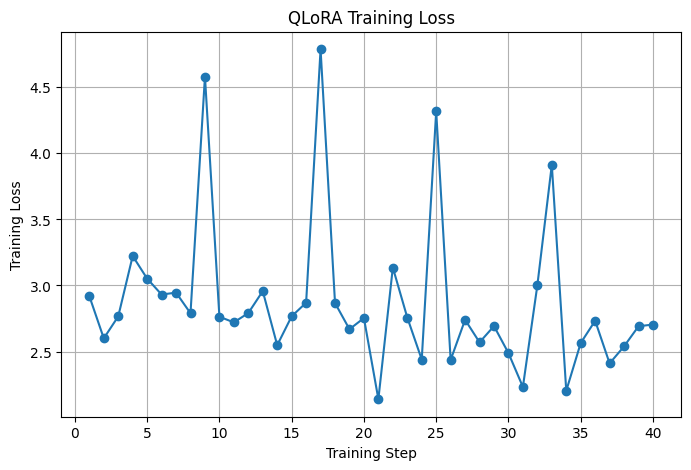


>> [OK] QLoRA loss history analysed.


In [55]:
# Stage 9I: Plot QLoRA training loss

import pandas as pd
import matplotlib.pyplot as plt

qlora_loss_records = [
    {
        "step": entry["step"],
        "loss": entry["loss"]
    }
    for entry in sft_trainer.state.log_history
    if "loss" in entry
]

qlora_loss_df = pd.DataFrame(
    qlora_loss_records
)

print("Stage 9I: QLoRA Loss History")
print("-----------------------------")
print(f"Logged training steps : {len(qlora_loss_df)}")

if len(qlora_loss_df) > 0:

    print(
        f"First logged loss     : "
        f"{qlora_loss_df.iloc[0]['loss']:.4f}"
    )

    print(
        f"Final logged loss     : "
        f"{qlora_loss_df.iloc[-1]['loss']:.4f}"
    )

    print(
        f"Minimum logged loss   : "
        f"{qlora_loss_df['loss'].min():.4f}"
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        qlora_loss_df["step"],
        qlora_loss_df["loss"],
        marker="o"
    )

    plt.xlabel("Training Step")
    plt.ylabel("Training Loss")
    plt.title("QLoRA Training Loss")
    plt.grid(True)

    plt.show()

print("\n>> [OK] QLoRA loss history analysed.")

### QLoRA Loss History Observation

The trainer logged the loss at every optimizer step, 40 in total over 5 epochs (8 steps per epoch). The first logged loss was 2.9196 and the final logged loss was 2.7045. The minimum was 2.1391, at step 21.

**Overall trend**
- Most steps sit between about 2.4 and 3.0. Steps 1 to 8 are mostly 2.6 to 3.2, steps 26 to 40 mostly 2.2 to 2.7, so the loss drifts downward.
- The final step (2.7045) is only about 7% below the first (2.9196). Single steps are noisy, so the validation loss in the training table (2.8238 → 2.5381, about 10%) is the better trend measure.

**Spikes**
- Four steps rise well above the rest: step 9 (about 4.6), step 17 (about 4.8), step 25 (about 4.3) and step 33 (about 3.9).
- They are exactly 8 steps apart, which is one epoch. Each falls on the first step of epochs 2, 3, 4 and 5. The first epoch has no such spike.
- Each spike is followed by a return to the normal range at the next step, and the loss does not stay high afterwards. The spike height falls in the last one (about 3.9), so they are not growing or causing divergence.
- The cause was not checked. The regular spacing points to something tied to the epoch boundary, such as how the 33 examples are grouped into batches of 4, rather than to the learning rate or to a bad example. Some of the lowest points also sit a few steps after a spike, such as step 21 (2.14) and step 34 (about 2.2).

**Interpretation**
- Each logged value is the loss on a single batch of 4 examples that mixes short and long answers, so large step-to-step swings are expected with only 33 training examples.
- The loss is still high in absolute terms (about 2.5 to 2.9 per token), and the plot has not flattened by step 40. More epochs or more data could lower it further.
- The spikes are cosmetic and the validation loss kept falling at every evaluation, so the training run is considered stable.

#### Stage 9J: Save QLoRA Adapter

The trained LoRA adapter is saved separately from the CPT checkpoint.

This preserves the lightweight instruction-tuning parameters while keeping the CPT model as the underlying domain-adapted base model.

The tokenizer is also saved alongside the adapter so that the same tokenization and chat-formatting configuration can be reused during later inference.

In [56]:
# Stage 9J: Save trained QLoRA adapter

from pathlib import Path

QLORA_ADAPTER_DIR = Path(
    "qlora_finance_adapter"
)

sft_trainer.model.save_pretrained(
    QLORA_ADAPTER_DIR
)

qlora_tokenizer.save_pretrained(
    QLORA_ADAPTER_DIR
)

print("Stage 9J: Adapter Checkpoint")
print("-----------------------------")
print(f"Saved directory: {QLORA_ADAPTER_DIR}")

print("\nFiles:")
for file_path in sorted(
    QLORA_ADAPTER_DIR.iterdir()
):
    print(f" - {file_path.name}")

print("\n>> [OK] QLoRA adapter saved.")

Stage 9J: Adapter Checkpoint
-----------------------------
Saved directory: qlora_finance_adapter

Files:
 - README.md
 - adapter_config.json
 - adapter_model.safetensors
 - merges.txt
 - special_tokens_map.json
 - tokenizer.json
 - tokenizer_config.json
 - vocab.json

>> [OK] QLoRA adapter saved.


#### Adapter Checkpoint Observation

The trained LoRA adapter and tokenizer were saved to `qlora_finance_adapter/`. The adapter is small because it holds only the 1,638,400 LoRA parameters, and it is meant to be loaded on top of the saved CPT model in `cpt_model/`.

## Step 8: QLoRA Evaluation

The trained finance adapter is evaluated using the same five instruction prompts used before continued pretraining.

This allows qualitative comparison between:

1. The original pretrained model.
2. The CPT-adapted model.
3. The CPT + QLoRA instruction-tuned model.

The objective is to determine whether QLoRA improves finance-domain instruction following and response quality.

#### Stage 10A: Evaluate the QLoRA Model on Domain Prompts

The trained QLoRA adapter is evaluated using the same five instruction prompts used during the earlier baseline and CPT evaluations.

Using identical prompts allows a direct qualitative comparison between the base model, the CPT-adapted model, and the CPT + QLoRA model.

The evaluation focuses on whether QLoRA improves:

- Relevance to the finance-domain question.
- Instruction-following behaviour.
- Response completeness.
- Reduction of repetition.
- Factual consistency with the domain material.

Generation uses deterministic decoding so that the responses are directly comparable across model stages.

In [57]:
# Stage 10A: Evaluate the trained QLoRA adapter

qlora_model = sft_trainer.model
qlora_model.eval()

# Same instruction prompts as Stage 5D (base) and Stage 7D (CPT)
DOMAIN_PROMPTS = domain_prompts

qlora_outputs = []

print("Stage 10A: Evaluate the trained QLoRA adapter")
print("---------------------------------------------\n")

for prompt in DOMAIN_PROMPTS:
    messages = [{"role": "user", "content": prompt}]
    formatted_prompt = qlora_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    response = generate_text(qlora_model, qlora_tokenizer, formatted_prompt)
    qlora_outputs.append(response)
    print("PROMPT:")
    print(prompt)
    print("\n>> QLORA RESPONSE:")
    print(response)
    print("-" * 70)

print("\n>> [OK] QLoRA evaluation completed.")


Stage 10A: Evaluate the trained QLoRA adapter
---------------------------------------------

PROMPT:
Explain the risks faced by individual traders in equity derivatives markets.

>> QLORA RESPONSE:
Individual traders face significant risks when trading in equity derivatives, including potential losses due to market movements and counterparty credit risk. To mitigate these risks, investors should conduct thorough research on underlying securities, select appropriate contracts based on their objectives, monitor market conditions closely, diversify portfolios across different asset classes, and maintain adequate insurance coverage.
----------------------------------------------------------------------
PROMPT:
Explain how UPI has contributed to the growth of digital payments in India.

>> QLORA RESPONSE:
Utkarsh Gupta, Head, Payments & Digital Banking at NPCI
----------------------------------------------------------------------
PROMPT:
What is a buy-back of securities and why might a comp

### QLoRA Evaluation Observation

QLoRA fine-tuning fixed the answer format and, after the pad-token fix, the stopping behaviour. It did not fix the facts.

**What improved**
- **Answers stop on their own:** All five responses end after one short paragraph or line. None runs on to the 150-token limit, and none starts a new `User:` turn or an invented "Question 2". In the earlier run, where the end-of-text token was masked by the pad setting, three of the five kept generating. The fix changed this behaviour: the end token is now a real training label (Stage 9G-check), and the model emits it.
- **Format:** Four of the five prompts get a direct explanatory answer. After CPT, three of them (traders, UPI, asset reconstruction companies) were continued as exam-paper question lists, so SFT taught the model to answer instead of continuing the document.
- **Prompt 5, Payments Vision:** It describes the Vision as "a roadmap for the future of payments" with "long-term vision, objectives and action points", which is close to the document's wording.

**What did not improve**
- **Prompt 1, traders:** The answer lists generic risks (market movements, counterparty credit risk, insurance coverage). It does not use the central finding of the SEBI study, that most individual traders lose money.
- **Prompt 2, UPI:** The answer is only "Utkarsh Gupta, Head, Payments & Digital Banking at NPCI". It does not explain how UPI grew digital payments, and the name is invented. The model produced a byline from the training text and then ended. This is a side effect of learning to stop: it can now stop too early.
- **Prompt 3, buy-back:** It still defines a buy-back as an IPO that "raises capital through the issue of new shares". A buy-back is a company purchasing its own shares, so the answer is wrong, and the same error appeared in the base and earlier QLoRA outputs.
- **Prompt 4, asset reconstruction companies:** It still says ARCs are "a group of private equity firms". ARCs are companies registered with the RBI, even though the training set has 5 ARC examples.
- **Prompt 5, Payments Vision:** It names the "Payment Systems Act, 1961". The Act is the Payment and Settlement Systems Act, 2007, so the name and the year are wrong. It also calls the RBI the "global leader in payment systems innovation", which is not from the source, and it does not list the Vision's goals, which was the question.

**Conclusion:** Fixing the end-of-text label made the model stop after its answer, which was the problem in the earlier run. The 33 training examples were still enough only to teach format and tone, not reliable facts. The model still invents names, figures and definitions, and one answer (Prompt 2) is now too short to be useful. Grounded answers would need retrieval or a much larger instruction set.

#### Stage 10B: Perplexity After QLoRA

Perplexity is measured again on the same 74 held-out blocks, this time for the CPT model loaded in 4-bit with and without the trained LoRA adapter. The comparison shows how much of the change comes from 4-bit loading and how much from QLoRA itself.

In [58]:
# Stage 10B: Perplexity of the CPT + QLoRA model on the same held-out blocks

qlora_model = sft_trainer.model
qlora_model.eval()

# CPT model in 4-bit, adapter switched off (isolates the effect of 4-bit loading)
with qlora_model.disable_adapter():
    cpt4_nll, cpt4_perplexity = calculate_perplexity(
        qlora_model, cpt_holdout_dataset, DEVICE
    )

# CPT model in 4-bit, adapter on (CPT + QLoRA)
qlora_nll, qlora_perplexity = calculate_perplexity(
    qlora_model, cpt_holdout_dataset, DEVICE
)

print("Stage 10B: Perplexity After QLoRA")
print("-" * 35)
print(f"Base model            : {base_perplexity:.4f}")
print(f"CPT model (original)  : {cpt_perplexity:.4f}")
print(f"CPT model (4-bit)     : {cpt4_perplexity:.4f}")
print(f"CPT + QLoRA (4-bit)   : {qlora_perplexity:.4f}")
print(f"\nQLoRA vs CPT (4-bit)  : {qlora_perplexity - cpt4_perplexity:+.4f}")

print("\n>> [OK] Post-QLoRA perplexity measured.")

Stage 10B: Perplexity After QLoRA
-----------------------------------
Base model            : 7.9047
CPT model (original)  : 6.3744
CPT model (4-bit)     : 6.9567
CPT + QLoRA (4-bit)   : 6.9492

QLoRA vs CPT (4-bit)  : -0.0075

>> [OK] Post-QLoRA perplexity measured.


### Post-QLoRA Perplexity Observation

Perplexity was measured on the same held-out finance blocks for all four model states.

| Model | Perplexity | Change vs base |
|---|---|---|
| Base SmolLM2-360M | 7.9047 | n/a |
| CPT model (original precision) | 6.3744 | 19.4% lower |
| CPT model (4-bit, adapter off) | 6.9567 | 12.0% lower |
| CPT + QLoRA (4-bit, adapter on) | 6.9492 | 12.1% lower |

**Effect of QLoRA:** With the adapter on, perplexity is 6.9492 against 6.9567 with the adapter off, a change of −0.0075 (about 0.1%). The adapter learned the instruction format without making the model better or worse at general finance text. This is the result expected, because the adapter was trained on 33 instruction examples and not on the corpus.

**Effect of 4-bit loading:** Loading the CPT model in 4-bit raises perplexity from 6.3744 to 6.9567, which is 9.1% higher. That gives back about 38% of the CPT gain (0.58 of the 1.53 points CPT removed), so most of the difference between the CPT and CPT + QLoRA figures comes from quantisation, not from QLoRA.

**Conclusion:** Compared with the base model, the final CPT + QLoRA model is 12.1% lower in perplexity, so the domain gain from CPT is still present after quantisation and fine-tuning. QLoRA did not cost any perplexity on the held-out text. It changes how the model answers, not how well it predicts the domain text.

## Step 9: Final Submission Verification

The completed pipeline now contains:

- PDF extraction and cleaning.
- Tokenization and packed CPT dataset construction.
- Base-model architecture inspection and baseline inference.
- Continued pretraining and loss analysis.
- Held-out perplexity and catastrophic-forgetting evaluation.
- Finance-domain instruction dataset creation.
- 4-bit QLoRA fine-tuning using the balanced adapter.
- Post-QLoRA evaluation on the original finance prompts.

The following checks verify that the required submission artifacts were generated successfully.

In [46]:
# Stage 11A: Verify submission artifacts

from pathlib import Path
import json

required_files = {
    "Instruction dataset":
        Path("instruction_dataset.jsonl"),

    "Instruction training split":
        Path("instruction_dataset_train.jsonl"),

    "Instruction evaluation split":
        Path("instruction_dataset_eval.jsonl"),

    "CPT model":
        Path("cpt_model"),

    "QLoRA adapter":
        Path("qlora_finance_adapter"),

    "Packed CPT dataset":
        Path("domain_corpus/packed_dataset.parquet"),
}

print("Stage 11A: Submission Artifact Verification")
print("--------------------------------------------")

all_present = True

for name, path in required_files.items():

    exists = path.exists()

    print(
        f"{name:<30}: "
        f"{'OK' if exists else 'MISSING'}"
    )

    if not exists:
        all_present = False


# Cleaned .txt corpus
cleaned_txt_files = sorted(
    Path("domain_corpus").glob("*.txt")
)

print(
    f"{'Cleaned corpus files':<30}: "
    f"{len(cleaned_txt_files)} found"
)


# Count JSONL records
def count_jsonl(path):
    if not path.exists():
        return 0

    with open(path, encoding="utf-8") as f:
        return sum(
            1 for line in f
            if line.strip()
        )


print("\nInstruction Dataset")
print("-------------------")

print(
    "Full dataset :",
    count_jsonl(
        Path("instruction_dataset.jsonl")
    )
)

print(
    "Training set :",
    count_jsonl(
        Path("instruction_dataset_train.jsonl")
    )
)

print(
    "Evaluation set:",
    count_jsonl(
        Path("instruction_dataset_eval.jsonl")
    )
)


assert len(cleaned_txt_files) == expected_pdf_count

assert count_jsonl(Path("instruction_dataset.jsonl")) == len(final_instruction_df)
assert count_jsonl(Path("instruction_dataset_train.jsonl")) == len(train_records)
assert count_jsonl(Path("instruction_dataset_eval.jsonl")) == len(eval_records)

assert all_present


print(
    "\n>> [OK] Required assignment artifacts "
    "are present."
)

Stage 11A: Submission Artifact Verification
--------------------------------------------
Instruction dataset           : OK
Instruction training split    : OK
Instruction evaluation split  : OK
CPT model                     : OK
QLoRA adapter                 : OK
Packed CPT dataset            : OK
Cleaned corpus files          : 18 found

Instruction Dataset
-------------------
Full dataset : 41
Training set : 33
Evaluation set: 8

>> [OK] Required assignment artifacts are present.


### Submission Artifact Verification Observation

All required artifacts are present: the full instruction dataset (41 examples), the training split (33) and evaluation split (8), the CPT model, the QLoRA adapter, the packed CPT dataset, and 18 cleaned corpus files. The counts match the earlier stages, so the three pipeline outputs agree with one another.

#### Stage 11B: Output Directories

Every folder and file written by this run is listed with its full path, file count and size. The extracted raw text (`domain_corpus/raw`), the cleaned corpus and packed dataset (`domain_corpus`), the CPT and QLoRA outputs, and the instruction JSONL files should all sit under the working directory, `/home/group157`.

In [59]:
# Stage 11B: Output directories and files written by this run

from pathlib import Path


def human_size(num_bytes):
    size = float(num_bytes)
    for unit in ("B", "KB", "MB", "GB"):
        if size < 1024 or unit == "GB":
            return f"{int(size)} B" if unit == "B" else f"{size:,.1f} {unit}"
        size /= 1024


def show_directory(label, path, recursive=False, max_files=20):
    path = Path(path)
    print(f"{label}")
    print(f"  path : {path.resolve()}")
    if not path.exists():
        print("  >> [MISSING]\n")
        return
    pattern = path.rglob("*") if recursive else path.glob("*")
    files = sorted(p for p in pattern if p.is_file())
    total = sum(p.stat().st_size for p in files)
    print(f"  files: {len(files)}   size: {human_size(total)}")
    for p in files[:max_files]:
        print(f"    - {p.relative_to(path)}  ({human_size(p.stat().st_size)})")
    if len(files) > max_files:
        print(f"    ... and {len(files) - max_files} more files")
    print()


print("Stage 11B: Output Directories")
print("-" * 31)
print(f"Working directory: {Path.cwd()}\n")

show_directory("Extracted raw text (Stage 2)",      "domain_corpus/raw")
show_directory("Cleaned corpus + packed dataset",   "domain_corpus")
show_directory("CPT trainer output",                "cpt_output", recursive=True)
show_directory("CPT model (Stage 6F)",              "cpt_model")
show_directory("QLoRA trainer output",              "qlora_training_output", recursive=True)
show_directory("QLoRA adapter (Stage 9J)",          "qlora_finance_adapter")

print("Files in the working directory")
for name in ("instruction_dataset.jsonl", "instruction_dataset_train.jsonl",
             "instruction_dataset_eval.jsonl", "cpt_loss.png"):
    p = Path(name)
    status = human_size(p.stat().st_size) if p.exists() else "MISSING"
    print(f"  - {name}  ({status})")

print("\n>> [OK] Output directories listed.")


Stage 11B: Output Directories
-------------------------------
Working directory: /home/group157

Extracted raw text (Stage 2)
  path : /home/group157/domain_corpus/raw
  files: 18   size: 2.7 MB
    - Profitability of Individual Traders in the Equity Derivatives Segment (FY25–FY26).txt  (138.1 KB)
    - RBI - Asset Reconstruction Companies Directions 2025.txt  (127.7 KB)
    - RBI - Asset Reconstruction Companies – Credit Information Reporting Directions 2025.txt  (73.3 KB)
    - RBI - Asset Reconstruction Companies – Know Your Customer Directions 2025.txt  (160.5 KB)
    - RBI - Asset Reconstruction Companies – Treatment of Wilful Defaulters and Large Defaulters Directions 2025.txt  (17.0 KB)
    - RBI - Benchmarking Indias Payments Systems - 2022.txt  (139.4 KB)
    - RBI - Digitalisation and Payment Revolution in India 2024.txt  (101.1 KB)
    - RBI - Master Direction on Regulation of Payment Aggregator.txt  (43.1 KB)
    - RBI - Payment and Settlement Systems and Information Techno

#### Stage 11C: Compress Deliverables

Packs `domain_corpus/*.txt` and `instruction_dataset.jsonl` into one `deliverables.zip` so they can be downloaded from the file browser in a single step.

In [60]:
# Stage 11C: Compress the deliverables into one zip for download
import zipfile
from pathlib import Path

ZIP_NAME = "deliverables.zip"
files = sorted(Path("domain_corpus").glob("*.txt")) + [Path("instruction_dataset.jsonl")]

with zipfile.ZipFile(ZIP_NAME, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in files:
        zf.write(f, arcname=str(f))

print(f"Created {ZIP_NAME}: {Path(ZIP_NAME).stat().st_size/1024:.1f} KB, {len(files)} files")
for f in files:
    print("  ", f)


Created deliverables.zip: 771.9 KB, 19 files
   domain_corpus/Profitability of Individual Traders in the Equity Derivatives Segment (FY25–FY26).txt
   domain_corpus/RBI - Asset Reconstruction Companies Directions 2025.txt
   domain_corpus/RBI - Asset Reconstruction Companies – Credit Information Reporting Directions 2025.txt
   domain_corpus/RBI - Asset Reconstruction Companies – Know Your Customer Directions 2025.txt
   domain_corpus/RBI - Asset Reconstruction Companies – Treatment of Wilful Defaulters and Large Defaulters Directions 2025.txt
   domain_corpus/RBI - Benchmarking Indias Payments Systems - 2022.txt
   domain_corpus/RBI - Digitalisation and Payment Revolution in India 2024.txt
   domain_corpus/RBI - Master Direction on Regulation of Payment Aggregator.txt
   domain_corpus/RBI - Payment and Settlement Systems and Information Technology 2025-26.txt
   domain_corpus/RBI - Payments Vision 2025.txt
   domain_corpus/RBI - UPI Annual Report 2025-26.txt
   domain_corpus/SEBI - Bu

### Final Model Comparison

| | Base SmolLM2-360M | After CPT | After CPT + QLoRA |
|---|---|---|---|
| Training data | none (original model) | 18 finance PDFs, 655 blocks (670,720 tokens), 2 epochs | 33 grounded Q&A pairs, 5 epochs |
| Trainable parameters | n/a | all 360M | 1,638,400 adapter parameters (0.45%) |
| Training time | n/a | about 3 min 16 s | 53.60 s |
| Held-out perplexity | 7.9047 | 6.3744 (19.4% lower) | 6.9492 (12.1% lower than base; 4-bit) |
| Validation loss (instruction data) | n/a | n/a | 2.8238 → 2.5381 |
| Answers the question asked | Partly, with drift into unrelated Q&A | Usually not: continues as exam-style text | Mostly: an explanatory paragraph (Prompt 2 returned only a name) |
| Domain vocabulary | Weak, with wrong definitions of buy-back, ARC and security receipt | Better (NPCI, ARC, "specified securities", ₹ units) | Uses domain terms and the Payments Vision wording |
| Factual accuracy | Poor | Poor: invents years, figures and the number of pillars | Poor: invents names, figures and organisations, and defines a buy-back as an IPO |
| General knowledge retained | Baseline | Mostly (fluency held, 1 of 5 prompts degraded) | not tested |
| Stops after the answer | No | No | Yes (all 5 answers end on their own) |

CPT loaded in 4-bit scores 6.9567, so QLoRA itself changed perplexity by −0.0075. The 6.9492 figure is higher than the CPT model's 6.3744 only because of 4-bit loading.

**Summary:** CPT lowered held-out perplexity by 19.4% with little overlap (2.7%) between training and held-out text. It shifted vocabulary and style toward Indian financial documents, but it did not make the model more accurate. QLoRA corrected the answer format, from document continuation to an explanatory paragraph, and taught the model to stop after its answer, without changing perplexity. The stopping behaviour came from keeping the end-of-text token as a training label, with a separate pad token. The model still invents facts, because 33 examples can teach a format but not knowledge, and one answer (Prompt 2) now ends too early. Further gains would come from more grounded instruction examples or retrieval over the source documents.